# Outline Python script for the MS3.08 Introduction to Computer Controlled Experiments
Experiments conducted by **Devan Hu** and **Angze Li**.
### Version 1.1 - Updated 7 October 2025 by BFS
Nick Brooks

# Aim of the Experiment

The aim of this experiment is to measure and analyse the current–voltage (I–V) characteristics of light-emitting diodes (LEDs) using a computer-controlled Arduino-based data acquisition system programmed in Python, in order to investigate how electronic structure and material properties influence charge transport behaviour.

Specifically, the experiment aims to achieve:

1. Characterise the non-ohmic I–V behaviour of LEDs and relate it to Shockley diode theory.

2. Compare LEDs of different emission colours, including white, to determine differences in turn-on voltage and infer variations in semiconductor energy band gap.

3. Investigate the temperature dependence of LED turn-on voltage, linking thermal effects to changes in carrier dynamics and band structure.

4. Measure and compare the I–V behaviour of a standard resistor, demonstrating ohmic conduction in contrast to diode behaviour.

5. Use this comparison to highlight how material properties and electronic structure govern whether a component follows Ohm’s law (I = V/R) or diode-like exponential behaviour.

Through direct comparison of LEDs and a standard resistor, the experiment aimed to demonstrate the fundamental distinction between linear resistive conduction and non-linear semiconductor conduction, reinforcing the relationship between macroscopic electrical measurements and microscopic material properties.

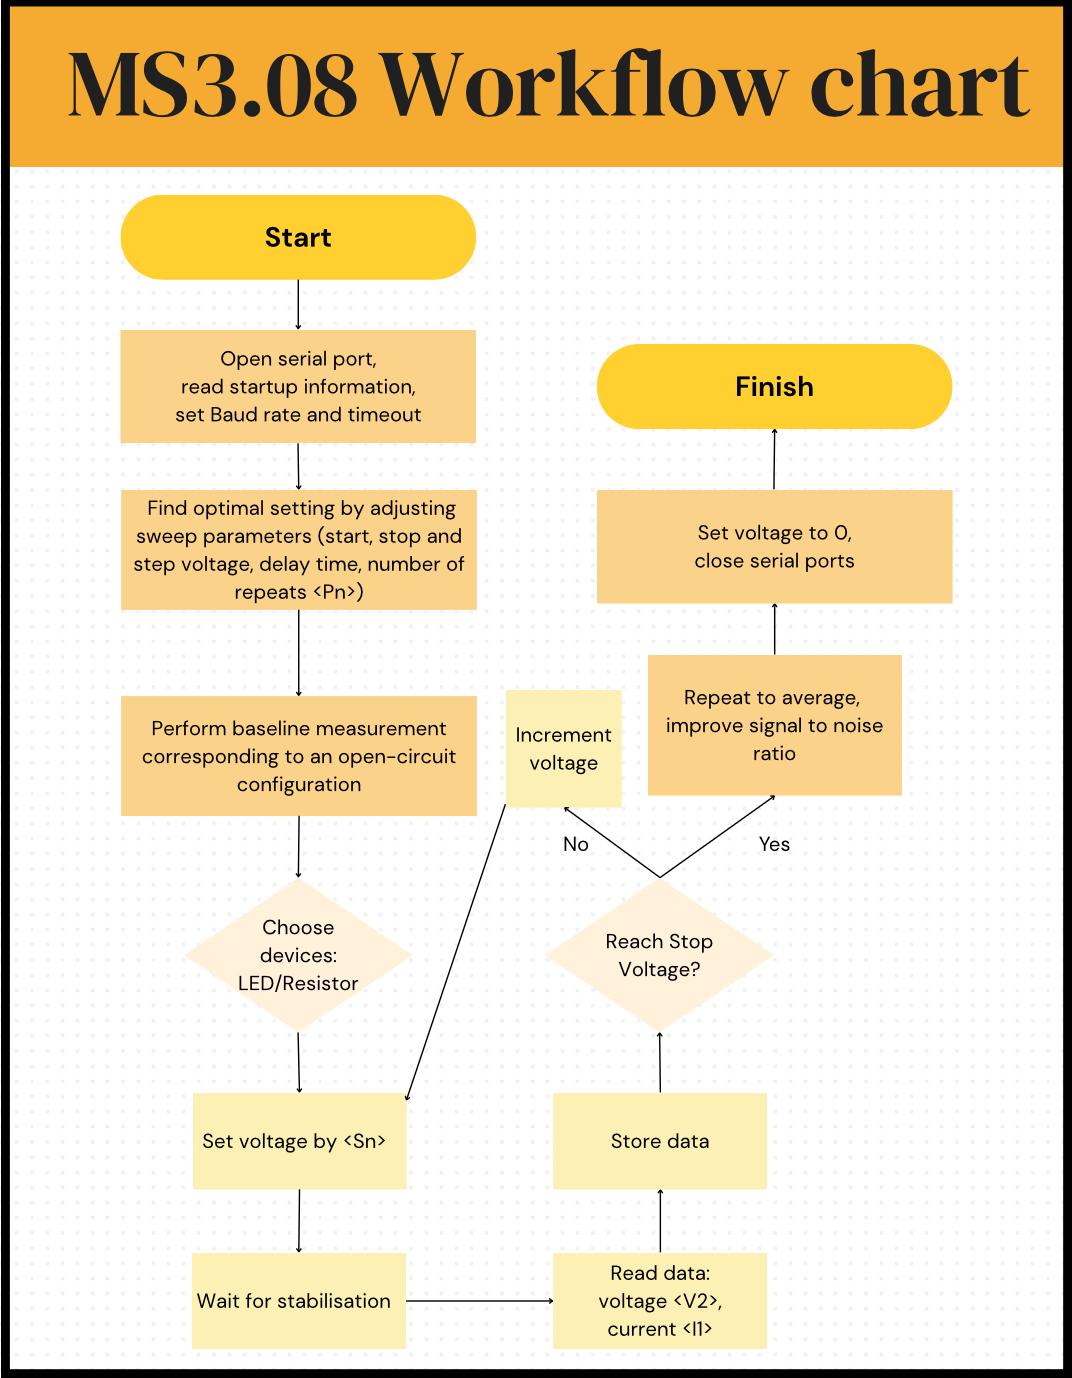

# Instructions

This notebook provides an outline for developing a program that will allow you to investigate the conductivity of simple electronic components. It communicate with an Arduino that is configured to provide as a voltage source, as well as read the potential across the test component and current flowing through it. A full description of the experiment and the way that you communicate with the Arduino is available on Blackboard. 
Before you begin, you will need to install a module that lets Python communicate through a serial connection with other pieces of equipment. You only need to do this once to get everything set up.

Before you start, you need to install a Python module that allows you to work with serial connections to your computer, you only need to do this once and it will stay installed in your Python distribution.

Run the cell below and wait for the module to download and install.

In [66]:
pip install pyserial

Note: you may need to restart the kernel to use updated packages.


If you receive a 'syntax error' when running to command above, please run the same command in a terminal window. If you are using Windows, you can launch a terminal window by typing CMD into the main Windows search bar (this is usually towards the left of the main toolbar at the bottom of your screen) and running the CMD program. If you are using MacOS or Linux, you can open the 'Terminal' program from your application launcher.

Next you need to point the program that you'll be writing towards the libraries that it will need to run. The libraries that you need are the 'serial' library that contains the commands for serial communicaiton, some parts of serial tools so you can find the name of the port that your instrument is connected to, 'time' for allowing your program to wiat and the standard tools that you have used in the past for data manipulation, curve plotting and fitting.<br>
Run the cell below to import the appropriate libraries.

In [204]:
import os, csv, time
import serial
import serial.tools.list_ports
import time
%pylab inline
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import csv
from datetime import datetime

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


So that you can tell your program where to send and receive information, you need to find the name of the port that you have connected your instrument to. The port is a virtual serial port that runs over the USB connection (effectively the serial commands are send over USB and then decoded in the instrument).<br>
Start by making sure that your Arduino is <b>disconnected</b> from your computer, run the cell below and make a note of the port names that show up (there may be no ports shown at this point). Next <b>connect</b> your instrument to a USB port on your computer, wait for a moment to check that any required drivers are installed (on Windows you may see a message saying that your device is being prepared and then one to say that it is ready for use), and then run the cell below again to get an updated list of the available serial ports. The name of the extra port that shows up with your Arduino connected is the one that you should use in the subsequent code.
Note that the port naming scheme is different depending on your opperating systems:<br>
<b>Windows.</b> If you are using Windows, your Arduino will show up on a port named 'COM' and then a number (e.g. COM7).<br>
<b>MacOS or Linux.</b> If you are using MacOS or Linux, your Arduino port will be named similar to '/dev/cu.usbmodem' and then a number.

In [192]:
ports = serial.tools.list_ports.comports()

for p in ports:
    print(p.device)
print (len(ports), 'ports found') 

/dev/cu.debug-console
/dev/cu.Bluetooth-Incoming-Port
/dev/cu.usbmodem2101
3 ports found


To open the serial connection between your computer and Arduino, you need to specify the parameters that the Arduino uses to communicate. You will need to specify the port name, a baud rate (the number of bits per second) of 9600, and a timeout time of 2 seconds.<br>
You can use the following code outline to open a serial conection that we're going to name 'ser':<br>
```python
ser = serial.Serial('port name', baudrate=x, timeout=x)```

For example (note that you will need to change the port name to match the one found above):

```python
ser = serial.Serial('/dev/cu.usbmodem144301', baudrate=9600, timeout=2)```

In [193]:
ser = serial.Serial('/dev/cu.usbmodem2101', baudrate=9600, timeout=2)

When the serial connection is opened, the Arduino will reset and it will send three lines of information back to the computer. You can read each line into a variable called ```b``` using the code:
```python
b = ser.readline()```

The text is read in as a list of 8-bit characters which you can print out directly, but it may be useful to convert it to a string. You can use the following code to covert the chracter list to a string named ```readstring```:

```python
readstring = b.decode("utf-8")```

Finally, you can print each line as it is read using:

```python
print(readstring)```

You may find it useful to run these commands in a ```for``` loop that repeats 3 times rather than just repeating then 3 times explicitly.

In [194]:
for i in range(3):
    b = ser.readline()
    readstring = b.decode("utf-8")
    readstring
    print(readstring)

Imperial College London - Department of Chemistry

Year 3 Physical Chemistry Lab

Version NB1.0 - 8-9-20



Next, you should try to send some commands to the Arduino and then read back the response.<br>
You can send a command using the code: ```ser.write(bytestowrite)```, but remember from above that the information is sent and received as a list of 8-bit characters which is subtally different from a python string. To get a command ready to send, you need to define a string to send, for example using:
```python
writestring = '<S0>'```
Then this string needs to be encoded as a list of 8-bit ASCII characters using:
```python
bytestowrite = writestring.encode()```
After the command has been sent, the Arduino will receive it, process is and respond with one line which you should read as you did in the cell above (but remember there will only be one line now rather than three).

In [195]:
writestring = '<S0.00>'
bytestowrite = writestring.encode()
ser.write(bytestowrite)

7

In [196]:
response = ser.readline()
print(response.decode('utf-8'))

S 0.000



Now try to set up a loop that sets the applied voltage in small steps between 0 and 5 volts and at each step reads the current running through the LED, and the voltage across it. You will need to store each reading in a list so you can plot them later. You should think about if it is appropriate to insert short delays in the program (for instance to allow the set voltage to stabilise before reading your data), you can do this using the command:
```python
time.sleep(0.1)```
Where the number in brackets is the number of seconds to wait (100 ms in the example above).

Plot out your data and think about how you could extend the experiment, for example, can you measure multiple LEDs and compare their response, how does the response of an LED compare to a standard resistor?

When you are finished, you should close the serial connection. Only one program at a time can send information to a particular serial port, so by closing the connection, you free it up so that other programs could communicate with your instrument. Make sure you open the connection again when you want to start working again.<br>
You can close the connection using the following command:
```python
ser.close()```


In [214]:
ser.close()

# 0. Functions
All functions required for the ICCE LED/Resistor I–V experiments (Experiments 1–5) are defined in this cell. No experimental measurements are executed in this cell. Execution is performed explicitly in subsequent cells.

In [211]:
# =========================================================
# 0) OUTPUT ROOTS
# =========================================================
FIG_ROOT = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures"
CSV_ROOT = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised"


# =========================================================
# 1) TIMESTAMP + PATH HELPERS
# =========================================================
def make_timestamp():
    return datetime.now().strftime("%Y%m%d_%H%M%S")

def safe_tag(x, ndp=3):
    # e.g. 0.01 -> "0p01", 0.3 -> "0p3"
    return f"{x:.{ndp}f}".rstrip("0").rstrip(".").replace(".", "p")

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

def exp_dirs(exp_name):
    """
    Create and return (fig_dir, csv_dir) for a given experiment name.
    """
    fig_dir = ensure_dir(os.path.join(FIG_ROOT, exp_name))
    csv_dir = ensure_dir(os.path.join(CSV_ROOT, exp_name))
    return fig_dir, csv_dir


# =========================================================
# 2) CONSISTENT PLOT STYLING
# =========================================================
def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.tick_params(axis='both', width=1.8, length=6)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')
        t.set_fontsize(14)

def style_legend(leg):
    frame = leg.get_frame()
    frame.set_facecolor('white')
    frame.set_edgecolor('black')
    frame.set_linewidth(1.2)
    frame.set_alpha(0.85)


# =========================================================
# 3) SERIAL PARSING + ACQUISITION
# =========================================================
def parse_reply(line, cmd_name):
    """
    Arduino replies usually look like: b'V 1.234\\r\\n' or b'I 0.056\\r\\n'
    We parse the second token as float.
    """
    parts = line.decode(errors="replace").strip().split()
    if len(parts) < 2:
        raise RuntimeError(f"Bad {cmd_name} reply: {parts} (raw={line!r})")
    return float(parts[1])

def acquire_iv_sweep(
    ser,
    v_start=0.0,
    v_stop=5.0,
    v_step=0.1,
    delay=0.1,
    Pn=200,
    eps=1e-12
):
    """
    The ONE place that talks to the Arduino:
    - sets averaging <P{Pn}>
    - sweeps <S..>
    - reads <V2> and <I1>
    Returns numpy arrays (V, I).
    """
    ser.write(f"<P{Pn}>".encode())
    ser.readline()  # ack

    V_list, I_list = [], []
    v = v_start
    while v <= v_stop + eps:
        ser.write(f"<S{v:.2f}>".encode())
        ser.readline()  # ack

        time.sleep(delay)

        ser.write(b"<V2>")
        V_meas = parse_reply(ser.readline(), "<V2>")

        ser.write(b"<I1>")
        I_meas = parse_reply(ser.readline(), "<I1>")

        V_list.append(V_meas)
        I_list.append(I_meas)
        v += v_step

    return np.array(V_list), np.array(I_list)


# =========================================================
# 4) REPEATS + TRIMMING + AVERAGING
# =========================================================
def trim_to_common_length(V_runs, I_runs):
    """
    Trim all runs to the shortest length, discarding FIRST extra points.
    (Handles 50 vs 51 where first point is junk.)
    """
    n = min(len(V) for V in V_runs)
    V_out, I_out = [], []
    for V, I in zip(V_runs, I_runs):
        if len(V) > n:
            drop = len(V) - n
            V, I = V[drop:], I[drop:]
        else:
            V, I = V[:n], I[:n]
        V_out.append(V)
        I_out.append(I)
    return V_out, I_out

def collect_repeats(ser, repeats, require_enter=False, **acq_kwargs):
    """
    Run acquire_iv_sweep() 'repeats' times.
    Returns:
      V_ref (n,)
      I_stack (repeats, n)
      I_avg (n,)
    """
    V_runs, I_runs = [], []
    for r in range(1, repeats + 1):
        if require_enter:
            input(f"Repeat {r}/{repeats}: press Enter to start...")
        V, I = acquire_iv_sweep(ser, **acq_kwargs)
        V_runs.append(V)
        I_runs.append(I)

    V_runs, I_runs = trim_to_common_length(V_runs, I_runs)
    V_ref = V_runs[0]
    I_stack = np.vstack(I_runs)
    I_avg = I_stack.mean(axis=0)
    return V_ref, I_stack, I_avg


# =========================================================
# 5) FITTING UTILITIES
# =========================================================
def fit_linear(V, I):
    """
    Fit I = mV + c, return (m,c,R,R2).
    Assumes I is in mA => R(ohm)=1000/m.
    """
    m, c = np.polyfit(V, I, 1)
    I_fit = m * V + c
    ss_res = np.sum((I - I_fit) ** 2)
    ss_tot = np.sum((I - np.mean(I)) ** 2)
    R2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    R = 1000 / m
    return (m, c, R, R2)

def fit_split_linear(V, I, V_split):
    """
    Two linear fits: below/above V_split.
    Also compute R_high and R2_high on the high region.
    """
    low = V < V_split
    high = V > V_split
    if low.sum() < 2 or high.sum() < 2:
        raise ValueError(f"Not enough points for split fit: low={low.sum()}, high={high.sum()}")

    m_low, c_low = np.polyfit(V[low], I[low], 1)
    m_high, c_high = np.polyfit(V[high], I[high], 1)

    I_high_fit = m_high * V[high] + c_high
    ss_res_high = np.sum((I[high] - I_high_fit) ** 2)
    ss_tot_high = np.sum((I[high] - np.mean(I[high])) ** 2)
    R2_high = 1 - ss_res_high / ss_tot_high if ss_tot_high != 0 else np.nan

    R_high = 1000 / m_high
    return (m_low, c_low), (m_high, c_high), R_high, R2_high


# =========================================================
# 6) SAVING CSV
# =========================================================
def save_repeats_csv(path, V, I_stack, I_avg=None):
    """
    Save one CSV containing:
      Voltage, Current_run1..runN, (optional) Current_avg
    """
    I_stack = np.array(I_stack)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        header = ["Voltage (V)"] + [f"Current_run{i+1} (mA)" for i in range(I_stack.shape[0])]
        if I_avg is not None:
            header += ["Current_avg (mA)"]
        w.writerow(header)

        for j in range(len(V)):
            row = [V[j]] + [I_stack[i, j] for i in range(I_stack.shape[0])]
            if I_avg is not None:
                row += [I_avg[j]]
            w.writerow(row)
    print(f"Saved CSV → {path}")


# =========================================================
# 7) PLOTTING BUILDING BLOCKS
# =========================================================
def plot_open_circuit_single(ax, V, I, repeat_idx=None):
    ax.scatter(V, I, s=28, color="0.25", label="Measured data")
    ax.plot(V, I, linewidth=2.2, color="0.25")

    title = "I–V plot, nothing connected"
    if repeat_idx is not None:
        title += f" — repeat {repeat_idx}"
    ax.set_title(title, fontsize=20, fontweight="bold")

    ax.set_xlabel("Voltage / V", fontsize=22, fontweight="bold")
    ax.set_ylabel("Current / mA", fontsize=22, fontweight="bold")

    leg = ax.legend(
        prop={"size": 11, "weight": "bold"},
        loc="upper left",
        frameon=True,
        fancybox=True
    )
    style_legend(leg)

def plot_resistor_single_with_fit(ax, V, I):
    m, c, R, R2 = fit_linear(V, I)
    I_fit = m * V + c

    data_color = '0.25'
    fit_color  = 'royalblue'
    ax.scatter(V, I, s=28, color=data_color, label="Resistor data")
    ax.plot(V, I_fit, linewidth=2.2, color=fit_color,
            label=f"Linear fit: R ≈ {R:.2f} Ω, $R^2$ = {R2:.5f}")

    ax.set_xlabel("Voltage / V", fontsize=22, fontweight="bold")
    ax.set_ylabel("Current / mA", fontsize=22, fontweight="bold")

def plot_led_avg_with_splitfits(
    ax,
    V, I_avg,
    led_label,
    V_split,
    color,
    repeats,
    delay_time=None,
    fit_mode="single"
):
    (m_low, c_low), (m_high, c_high), R_high, R2_high = fit_split_linear(V, I_avg, V_split)

    ax.plot(V, I_avg, "o-", color=color, label=f"{led_label} (avg of {repeats})")

    mask_low = V < V_split
    mask_high = V > V_split

    if fit_mode == "double":
        for V_seg, m, c, label in [
            (V[mask_low],  m_low,  c_low,  f"Linear fit (V < {V_split:.2f} V)"),
            (V[mask_high], m_high, c_high, f"Linear fit (V > {V_split:.2f} V)")
        ]:
            V_fit = np.linspace(V_seg.min(), V_seg.max(), 100)
            ax.plot(V_fit, m * V_fit + c, "--", linewidth=2.5, label=label)

    elif fit_mode == "single":
        V_fit = np.linspace(V[mask_high].min(), V[mask_high].max(), 100)
        ax.plot(
            V_fit, m_high * V_fit + c_high,
            "--", linewidth=2.5,
            label=f"Linear fit (V > {V_split:.2f} V)"
        )

    else:
        raise ValueError("fit_mode must be 'single' or 'double'")

    ax.axvline(V_split, linestyle=":", linewidth=2.5, label="~ turn-on voltage", color="grey")

    ax.text(
        0.02, 0.55,
        f"{led_label}\n"
        f"Above {V_split:.2f} V:\n"
        f"slope = {m_high:.3f} mA/V\n"
        f"R ≈ {R_high:.3f} Ω\n"
        f"$R^2$ = {R2_high:.4f}",
        transform=ax.transAxes,
        fontsize=12, fontweight="bold",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    ax.set_xlabel("Voltage / V", fontsize=22, fontweight="bold")
    ax.set_ylabel("Current / mA", fontsize=22, fontweight="bold")

    title = f"{led_label} I–V (averaged)"
    if delay_time is not None:
        title += f", delay time = {delay_time:.2f} s"
    ax.set_title(title, fontsize=18, fontweight="bold")

    return (m_low, c_low), (m_high, c_high), R_high, R2_high

def finalize_and_save(fig, ax, fig_path, legend=True, legend_loc="upper left", legend_size=11):
    style_axes(ax)
    if legend:
        leg = ax.legend(prop={'size': legend_size, 'weight': 'bold'}, loc=legend_loc,
                        frameon=True, fancybox=True)
        style_legend(leg)
    fig.tight_layout()
    fig.savefig(fig_path, dpi=600)
    print(f"Saved figure → {fig_path}")
    plt.show()

# =========================================================
# 8) EXPERIMENT 1.1: Green LED delay-time test (avg fig + one CSV per delay)
# =========================================================
def run_delay_time_test(
    ser,
    delays,
    repeats=5,
    led_label="Green LED",
    V_split=1.7,
    color="green",
    v_start=0.0, v_stop=5.0, v_step=0.1,
    Pn=200,
    require_enter_each_run=True,
    fit_mode="single" 
):
    fig_dir, csv_dir = exp_dirs("1_Delay_Time_Test")
    stamp = make_timestamp()

    for delay_time in delays:
        print(f"\n=== Delay time = {delay_time} s ===")

        V_ref, I_stack, I_avg = collect_repeats(
            ser, repeats,
            require_enter=require_enter_each_run,
            v_start=v_start, v_stop=v_stop, v_step=v_step,
            delay=delay_time, Pn=Pn
        )

        delay_tag = safe_tag(delay_time)
        csv_path = os.path.join(
            csv_dir,
            f"{led_label.replace(' ','_')}_delay_{delay_tag}s_repeats{repeats}_{stamp}.csv"
        )
        save_repeats_csv(csv_path, V_ref, I_stack, I_avg)

        fig, ax = plt.subplots(figsize=(8, 6))
        plot_led_avg_with_splitfits(
            ax,
            V_ref, I_avg,
            led_label=led_label,
            V_split=V_split,
            color=color,
            repeats=repeats,
            delay_time=delay_time,  
            fit_mode=fit_mode      
        )
        fig_path = os.path.join(
            fig_dir,
            f"{led_label.replace(' ','_')}_delay_{delay_tag}s_avg_{stamp}.png"
        )
        finalize_and_save(fig, ax, fig_path, legend=True, legend_size=11)

    print("\nExperiment 1 done.")

# =========================================================
# 9) EXPERIMENT 1.2: Green LED step-voltage test (avg fig + one CSV per step)
# =========================================================
def run_step_voltage_test(
    ser,
    steps,
    repeats=5,
    led_label="Green LED",
    V_split=1.9,
    color="green",
    delay=0.3,
    v_start=0.0, v_stop=5.0,
    Pn=200,
    fit_mode="single",
    require_enter_each_run=True

):
    fig_dir, csv_dir = exp_dirs("2_Step_Voltage_Test")
    stamp = make_timestamp()

    for step in steps:
        print(f"\n=== Step voltage = {step} V ===")

        V_ref, I_stack, I_avg = collect_repeats(
            ser, repeats,
            require_enter=require_enter_each_run,
            v_start=v_start, v_stop=v_stop, v_step=step,
            delay=delay, Pn=Pn
        )

        step_tag = safe_tag(step)
        csv_path = os.path.join(csv_dir, f"{led_label.replace(' ','_')}_step_{step_tag}V_repeats{repeats}_{stamp}.csv")
        save_repeats_csv(csv_path, V_ref, I_stack, I_avg)

        fig, ax = plt.subplots(figsize=(8, 6))
        plot_led_avg_with_splitfits(ax, V_ref, I_avg, led_label, V_split, color, repeats=repeats)
        ax.set_title(f"{led_label} I–V (averaged), step={step} V", fontsize=18, fontweight="bold")

        fig_path = os.path.join(fig_dir, f"{led_label.replace(' ','_')}_step_{step_tag}V_avg_{stamp}.png")
        finalize_and_save(fig, ax, fig_path, legend=True, legend_size=11)

    print("\nExperiment 2 done.")

# =========================================================
# 10) EXPERIMENT 2: Open-circuit baseline (5 separate figs + 1 CSV)
# =========================================================
def run_open_circuit_baseline(
    ser,
    repeats=5,
    v_start=0.0, v_stop=5.0, v_step=0.1,
    delay=0.1,
    Pn=200,
    fit_mode="single",
    require_enter_each_run=True
):
    fig_dir, csv_dir = exp_dirs("3_Open_Circuit_Baseline")
    stamp = make_timestamp()

    V_runs, I_runs = [], []

    for r in range(1, repeats + 1):
        if require_enter_each_run:
            input(f"Open circuit repeat {r}/{repeats}: press Enter to start...")

        V, I = acquire_iv_sweep(
            ser,
            v_start=v_start, v_stop=v_stop, v_step=v_step,
            delay=delay, Pn=Pn
        )
        V_runs.append(V); I_runs.append(I)

        fig, ax = plt.subplots(figsize=(8, 6))
        plot_open_circuit_single(ax, V, I, repeat_idx=r)
        fig_path = os.path.join(fig_dir, f"open_circuit_run{r}_{stamp}.png")
        finalize_and_save(fig, ax, fig_path, legend=False)

    V_runs, I_runs = trim_to_common_length(V_runs, I_runs)
    V_ref = V_runs[0]
    I_stack = np.vstack(I_runs)
    I_avg = I_stack.mean(axis=0)

    csv_path = os.path.join(csv_dir, f"open_circuit_repeats{repeats}_{stamp}.csv")
    save_repeats_csv(csv_path, V_ref, I_stack, I_avg)

    print("\nExperiment 3 done.")

# =========================================================
# 11) EXPERIMENT 3: Resistor (5 separate figs + 1 CSV)
# =========================================================
def run_resistor_iv_sweep(
    ser,
    repeats=5,
    v_start=0.0, v_stop=5.0, v_step=0.1,
    delay=0.1,
    Pn=200,
    fit_mode="single",
    require_enter_each_run=True
):
    fig_dir, csv_dir = exp_dirs("4_Resistor")
    stamp = make_timestamp()

    V_runs, I_runs = [], []

    for r in range(1, repeats + 1):
        if require_enter_each_run:
            input(f"Resistor repeat {r}/{repeats}: press Enter to start...")

        V, I = acquire_iv_sweep(
            ser,
            v_start=v_start, v_stop=v_stop, v_step=v_step,
            delay=delay, Pn=Pn
        )
        V_runs.append(V); I_runs.append(I)

        fig, ax = plt.subplots(figsize=(8, 6))
        plot_resistor_single_with_fit(ax, V, I)
        ax.set_title(f"I–V plot (resistor) — run {r}", fontsize=20, fontweight="bold")

        fig_path = os.path.join(fig_dir, f"resistor_run{r}_{stamp}.png")
        finalize_and_save(fig, ax, fig_path, legend=True, legend_size=11)

    V_runs, I_runs = trim_to_common_length(V_runs, I_runs)
    V_ref = V_runs[0]
    I_stack = np.vstack(I_runs)
    I_avg = I_stack.mean(axis=0)

    csv_path = os.path.join(csv_dir, f"resistor_repeats{repeats}_{stamp}.csv")
    save_repeats_csv(csv_path, V_ref, I_stack, I_avg)

    print("\nExperiment 4 done.")


# =========================================================
# 12) EXPERIMENT 4: 5 LED colours (each LED: 5 separate figs + 1 CSV)
# =========================================================
def run_led_colour_set(
    ser,
    led_specs,
    repeats=5,
    v_start=0.0, v_stop=5.0, v_step=0.1,
    delay=0.1,
    Pn=200,
    fit_mode="single",  
    require_enter_each_run=True
):

    fig_dir, csv_dir = exp_dirs("5_LED_Colours")
    stamp = make_timestamp()

    for led_label, spec in led_specs.items():
        color = spec["color"]
        V_split = spec["V_split"]

        print(f"\n=== {led_label} (V_split={V_split}) ===")

        led_fig_dir = ensure_dir(os.path.join(fig_dir, led_label.replace(" ", "_")))
        led_csv_dir = ensure_dir(os.path.join(csv_dir, led_label.replace(" ", "_")))

        V_runs, I_runs = [], []

        for r in range(1, repeats + 1):
            if require_enter_each_run:
                input(f"{led_label} repeat {r}/{repeats}: press Enter to start...")

            V, I = acquire_iv_sweep(
                ser,
                v_start=v_start, v_stop=v_stop, v_step=v_step,
                delay=delay, Pn=Pn
            )
            V_runs.append(V); I_runs.append(I)

            # Save figure for each run with split fits + textbox
            fig, ax = plt.subplots(figsize=(8, 6))
            plot_led_avg_with_splitfits(
            ax,
            V,
            I_avg=I,          # single run treated as "avg"
            led_label=led_label,
            V_split=V_split,
            color=color,
            repeats=1,
            delay_time=0.1,
            fit_mode=fit_mode
            )

            ax.set_title(f"I–V plot ({led_label} LED) — run {r}", fontsize=18, fontweight="bold")
            
            fig_path = os.path.join(led_fig_dir, f"{led_label.replace(' ','_')}_run{r}_{stamp}.png")
            finalize_and_save(fig, ax, fig_path, legend=True, legend_size=12)

        V_runs, I_runs = trim_to_common_length(V_runs, I_runs)
        V_ref = V_runs[0]
        I_stack = np.vstack(I_runs)
        I_avg = I_stack.mean(axis=0)

        csv_path = os.path.join(led_csv_dir, f"{led_label.replace(' ','_')}_repeats{repeats}_{stamp}.csv")
        save_repeats_csv(csv_path, V_ref, I_stack, I_avg)

    print("\nExperiment 5 done.")

# 1. Test Variables

**Aim** : 

The following experimental variables were modified to determine the optimal measurement conditions: the start and stop voltage, the voltage step size, and the delay time between successive readings.

**Explanation** : 

To optimise the experimental parameters in a controlled and systematic manner, a single LED was selected as a reference device for all parameter exploration. The green LED was chosen due to its moderate band gap, which places its turn-on behaviour between that of the lower-band-gap red and yellow LEDs and the higher-band-gap blue LED. This intermediate operating regime makes the green LED representative of the overall LED set, allowing measurement parameters to be optimised without biasing the procedure towards extreme operating conditions.

LEDs with higher band gaps operate at higher forward voltages, where the current–voltage (I–V) relationship is more strongly nonlinear. In this regime, the measured current becomes more sensitive to small voltage fluctuations and insufficient stabilisation time following each voltage step. Conversely, lower-band-gap LEDs exhibit earlier turn-on and more gradual current increases. Using an intermediate-band-gap LED therefore provides a balanced test case for exploring system-level parameters such as voltage range, step size, and delay time.

Once the optimal experimental parameters were determined using the green LED, these parameters were fixed and applied consistently across all LED colours to ensure measurement consistency and comparability.

## 1.0. Start and End Voltage

Explanation : 

As shown in various I-V plots below, the modification of start and end voltage is deemed unnecessary. This is due to:
1. The resistance of LEDs before turn-on voltage can be effectively seen as *infinite*, so start voltages do not affect the overall performance of LEDs;
2. Across different LEDs, the currents at ~2.5 V are already quite high and seems are automatically cut off by the microcontroller, so there is no point changing this value either 

## 1.1. Delay Time
Explanation :

To determine the optimal delay time between successive measurements, a dedicated function, run_green_led_iv_sweep, was defined to perform a complete I–V sweep for the green LED while varying only the delay time. When the function is called, the user inputs a delay time, which sets the stabilisation period between applying each voltage step and recording the voltage and current. Linear fits are applied to the measured data, and the slope of the high-voltage region is used to calculate an effective resistance as a measure of measurement stability.

Results and conclusion :

The function was repeatedly executed with delay times of 0.01 s, 0.05 s, 0.1 s, 0.15 s, 0.2 s, and 0.3 s. Short delay times produced unstable resistance values, indicating insufficient stabilisation, while longer delay times led to convergence of the extracted resistance. No significant improvement was observed beyond 0.1 s. Therefore, a delay time of 0.1 s was selected as the optimal balance between accuracy and experimental efficiency and was used for all subsequent measurements.


=== Delay time = 0.01 s ===
Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/1_Delay_Time_Test/Green_LED_delay_0p01s_repeats5_20260122_193254.csv
Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/1_Delay_Time_Test/Green_LED_delay_0p01s_avg_20260122_193254.png


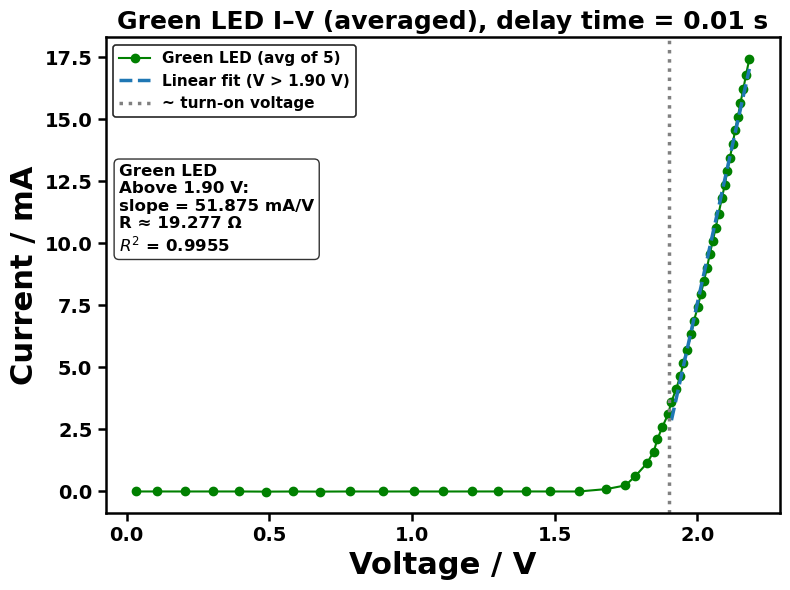


=== Delay time = 0.05 s ===
Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/1_Delay_Time_Test/Green_LED_delay_0p05s_repeats5_20260122_193254.csv
Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/1_Delay_Time_Test/Green_LED_delay_0p05s_avg_20260122_193254.png


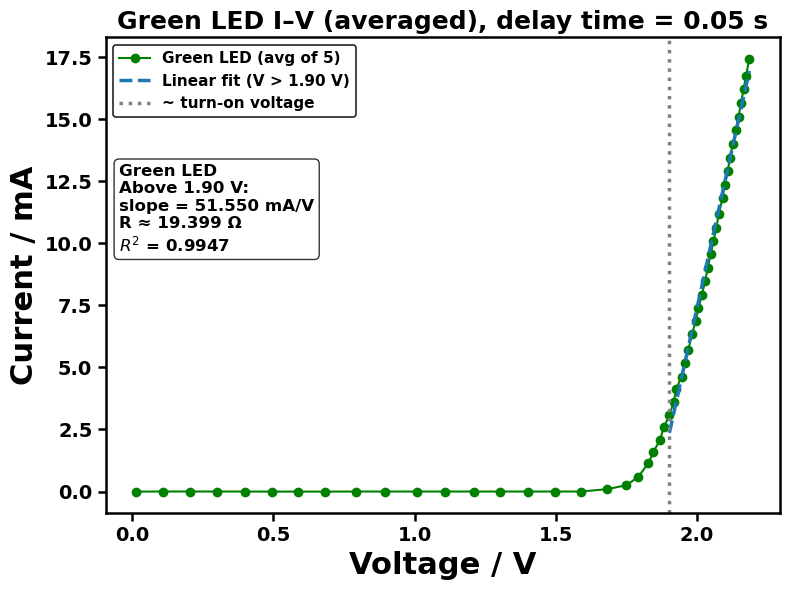


=== Delay time = 0.1 s ===
Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/1_Delay_Time_Test/Green_LED_delay_0p1s_repeats5_20260122_193254.csv
Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/1_Delay_Time_Test/Green_LED_delay_0p1s_avg_20260122_193254.png


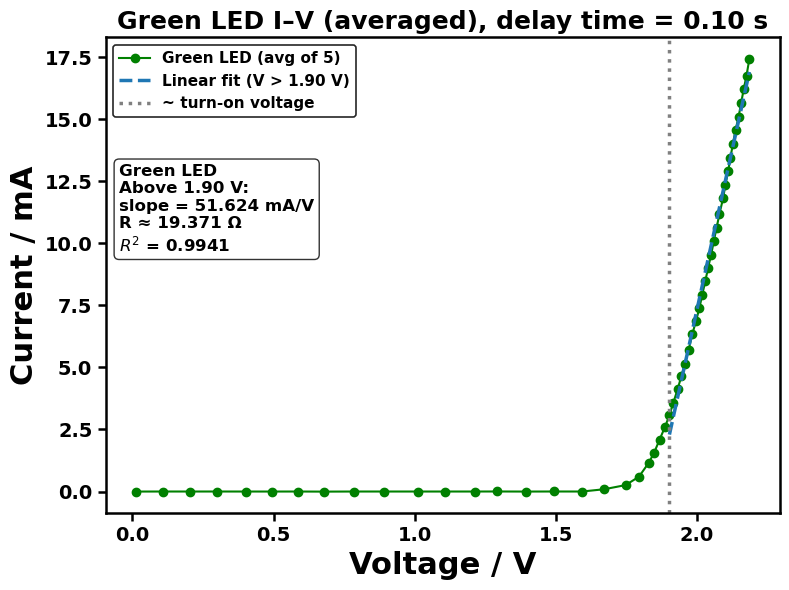


=== Delay time = 0.15 s ===
Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/1_Delay_Time_Test/Green_LED_delay_0p15s_repeats5_20260122_193254.csv
Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/1_Delay_Time_Test/Green_LED_delay_0p15s_avg_20260122_193254.png


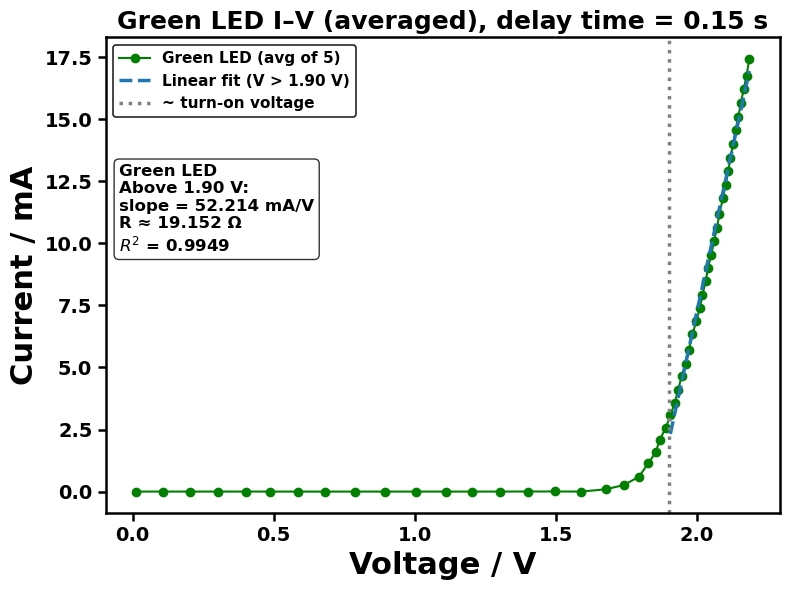


=== Delay time = 0.2 s ===
Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/1_Delay_Time_Test/Green_LED_delay_0p2s_repeats5_20260122_193254.csv
Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/1_Delay_Time_Test/Green_LED_delay_0p2s_avg_20260122_193254.png


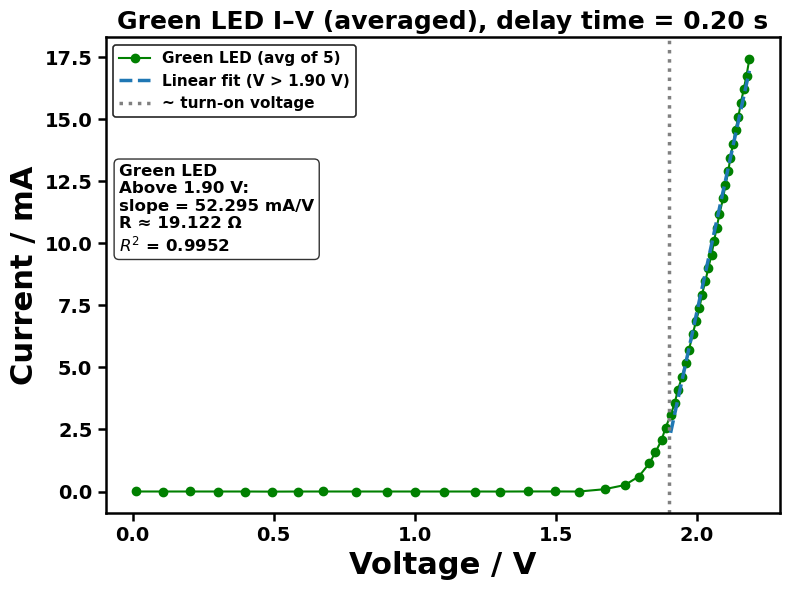


=== Delay time = 0.3 s ===
Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/1_Delay_Time_Test/Green_LED_delay_0p3s_repeats5_20260122_193254.csv
Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/1_Delay_Time_Test/Green_LED_delay_0p3s_avg_20260122_193254.png


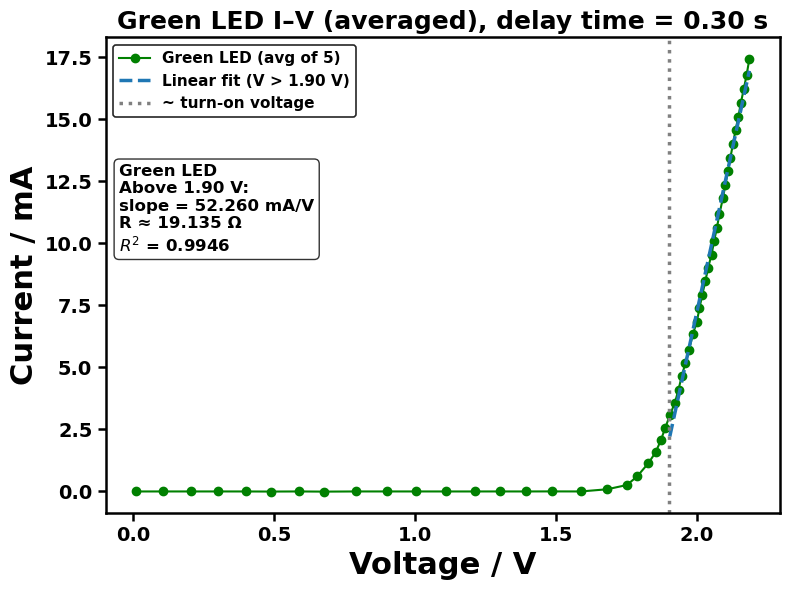


Experiment 1 done.


In [127]:
run_delay_time_test(
    ser=ser,
    delays=(0.01, 0.05, 0.10, 0.15, 0.20, 0.30),
    repeats=5,
    led_label="Green LED",
    V_split=1.9,
    color="green",
    v_step=0.1,
    Pn=200,
    require_enter_each_run=False,
    fit_mode="single"   # change to "double" for both fits
)

## 1.2. Step Voltage
Explanation :

To investigate the effect of voltage step size on the measured I–V characteristics, a second function, run_led_iv_sweep, was defined in which the step voltage is provided as a user input while all other experimental parameters, including the stabilisation delay, are held constant. Each execution of the function performs a complete I–V sweep over a fixed voltage range and applies linear fits to the low- and high-voltage regions of the data.

Step voltages that were too large resulted in insufficient data density for reliable linear fitting, while excessively small step sizes increased experimental duration without improving the extracted resistance. An intermediate step voltage was therefore selected to ensure reliable linear fitting while maintaining experimental efficiency.

Results and conclusion :

We tested 0.05 V, 0.1 V, 0.2 V, 0.5 V and 1 V and found that 0.1 V is the optimal balance between efficicency and accuracy. We have used an input structure to plot and save the figure directly, and therefore only one figure is shown in the Jupyter Notebook.


=== Step voltage = 0.05 V ===
Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/2_Step_Voltage_Test/Green_LED_step_0p05V_repeats5_20260122_195047.csv
Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/2_Step_Voltage_Test/Green_LED_step_0p05V_avg_20260122_195047.png


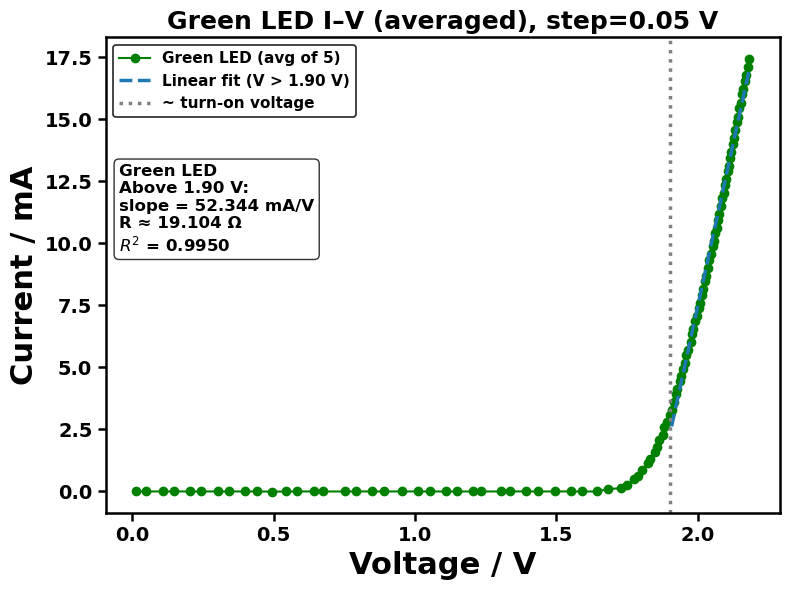


=== Step voltage = 0.1 V ===
Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/2_Step_Voltage_Test/Green_LED_step_0p1V_repeats5_20260122_195047.csv
Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/2_Step_Voltage_Test/Green_LED_step_0p1V_avg_20260122_195047.png


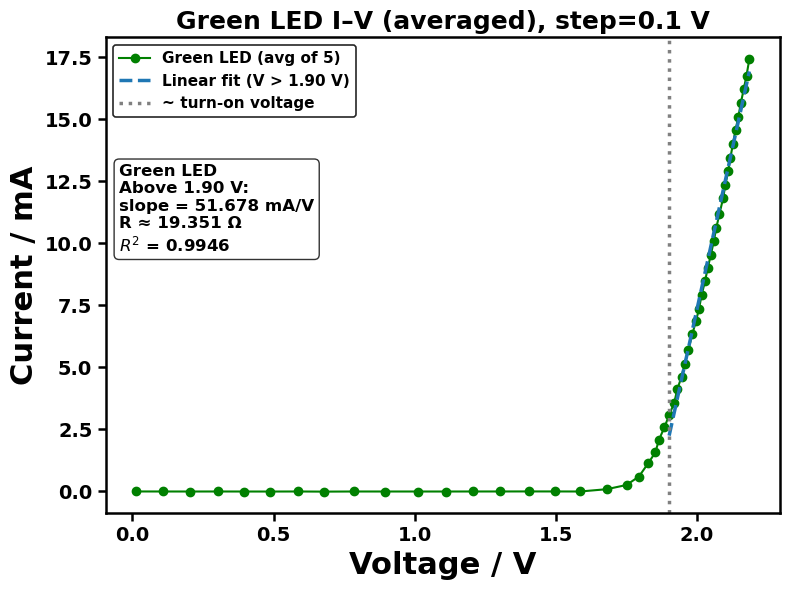


=== Step voltage = 0.2 V ===
Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/2_Step_Voltage_Test/Green_LED_step_0p2V_repeats5_20260122_195047.csv
Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/2_Step_Voltage_Test/Green_LED_step_0p2V_avg_20260122_195047.png


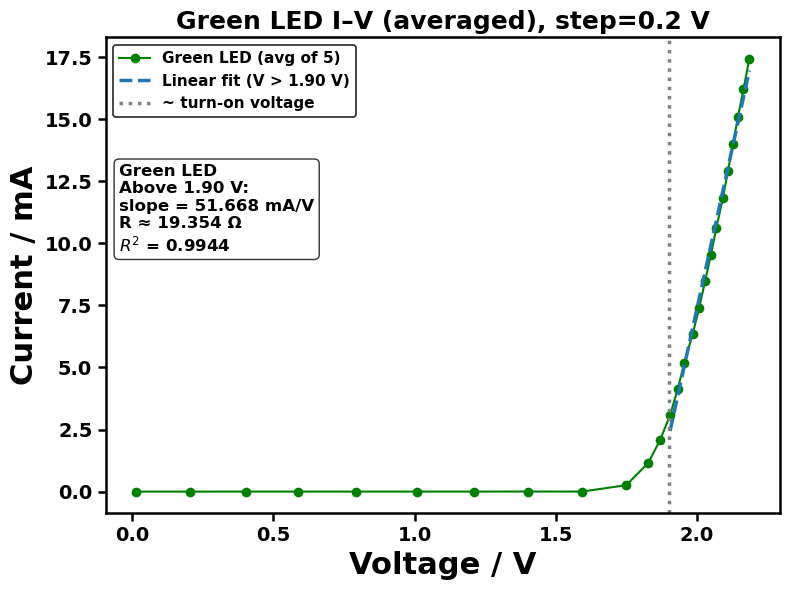


=== Step voltage = 0.5 V ===
Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/2_Step_Voltage_Test/Green_LED_step_0p5V_repeats5_20260122_195047.csv
Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/2_Step_Voltage_Test/Green_LED_step_0p5V_avg_20260122_195047.png


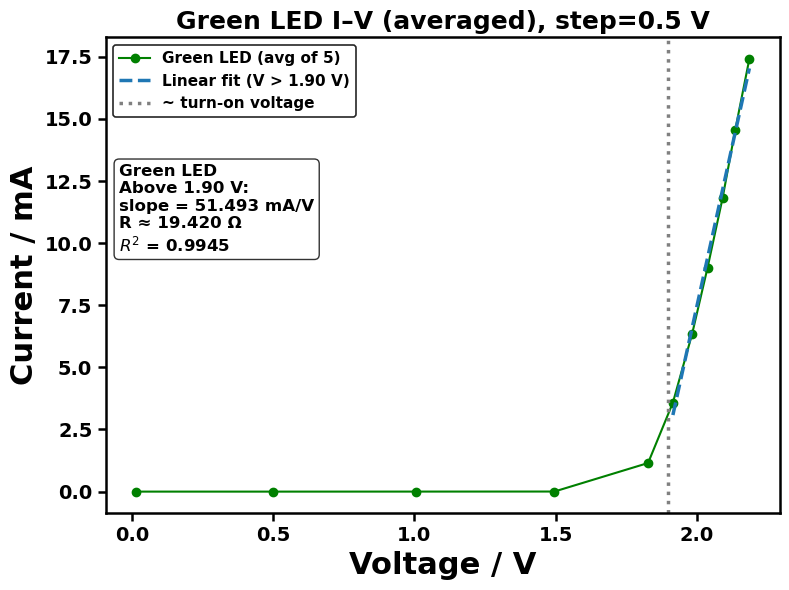


=== Step voltage = 1.0 V ===
Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/2_Step_Voltage_Test/Green_LED_step_1V_repeats5_20260122_195047.csv
Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/2_Step_Voltage_Test/Green_LED_step_1V_avg_20260122_195047.png


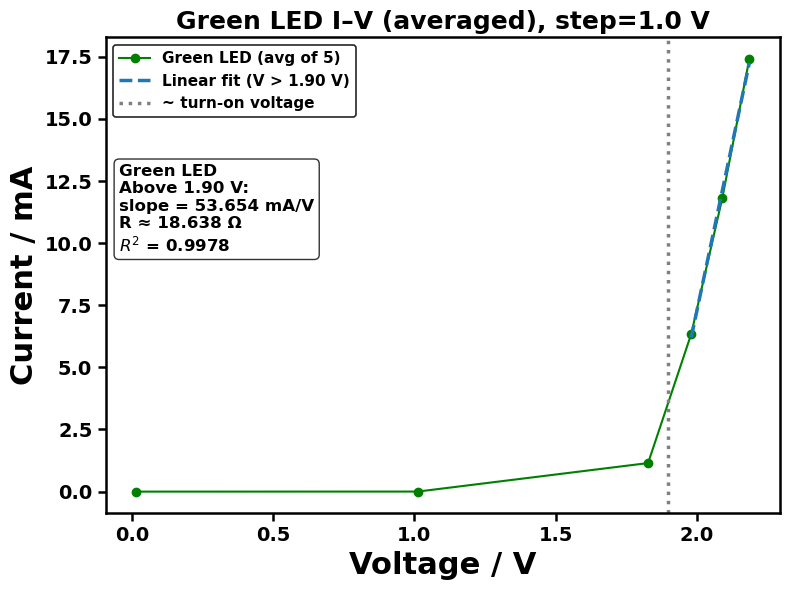


Experiment 2 done.


In [143]:
run_step_voltage_test(
     ser,
     steps=(0.05, 0.10, 0.20, 0.50, 1.00),
     repeats=5,
     led_label="Green LED",
     V_split=1.9,
     color="green",
     delay=0.1,
     Pn=200,
     fit_mode="single",   # change to "double" for both fits
     require_enter_each_run=False
 )

# 2. I-V Characteristics

## 2.1. Nothing Connected

**Explanation** : 

Baseline measurement was performed with no LED or standard resistor connected,
corresponding to an open-circuit configuration.

The current is calculated as:
    I = (A0 - A1) / R

For an ideal open circuit, A0 ≈ A1, and therefore I ≈ 0. Repeated measurements under identical conditions produced different readings, indicating random errors from the current readings.

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/3_Open_Circuit_Baseline/open_circuit_run1_20260122_201328.png


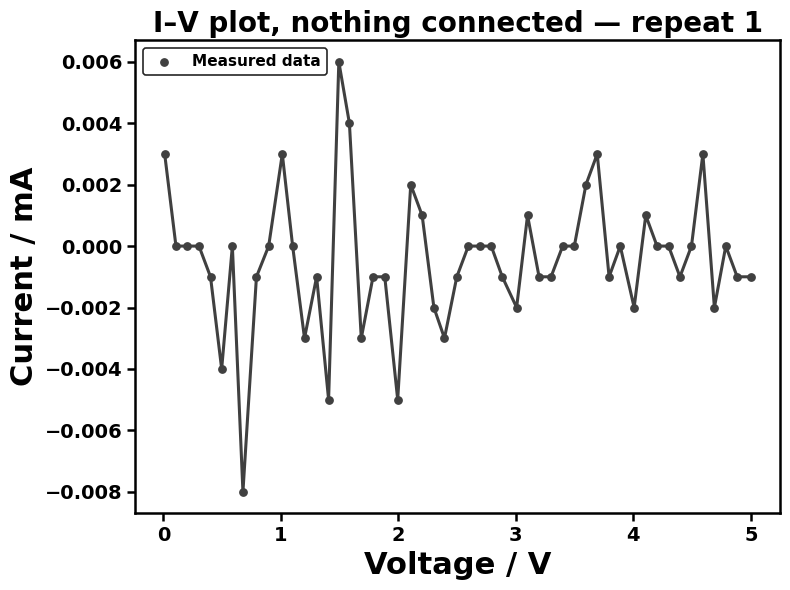

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/3_Open_Circuit_Baseline/open_circuit_run2_20260122_201328.png


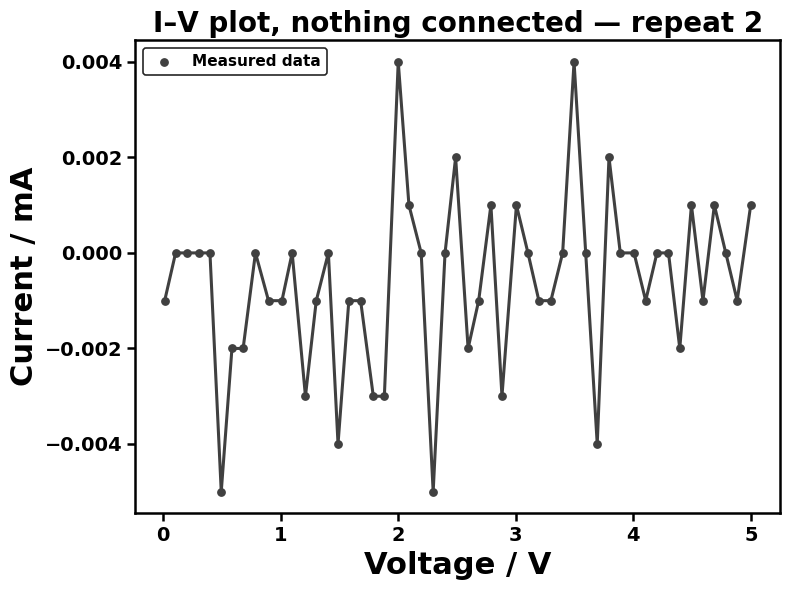

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/3_Open_Circuit_Baseline/open_circuit_run3_20260122_201328.png


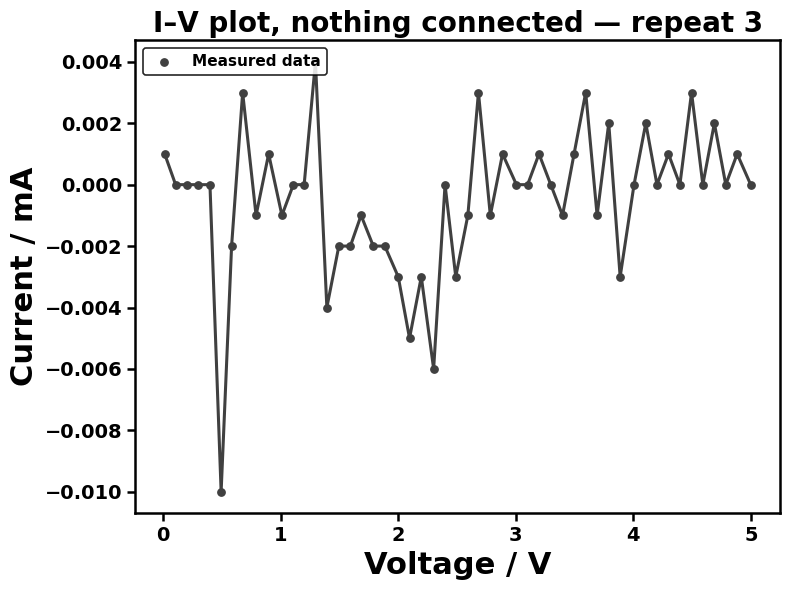

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/3_Open_Circuit_Baseline/open_circuit_run4_20260122_201328.png


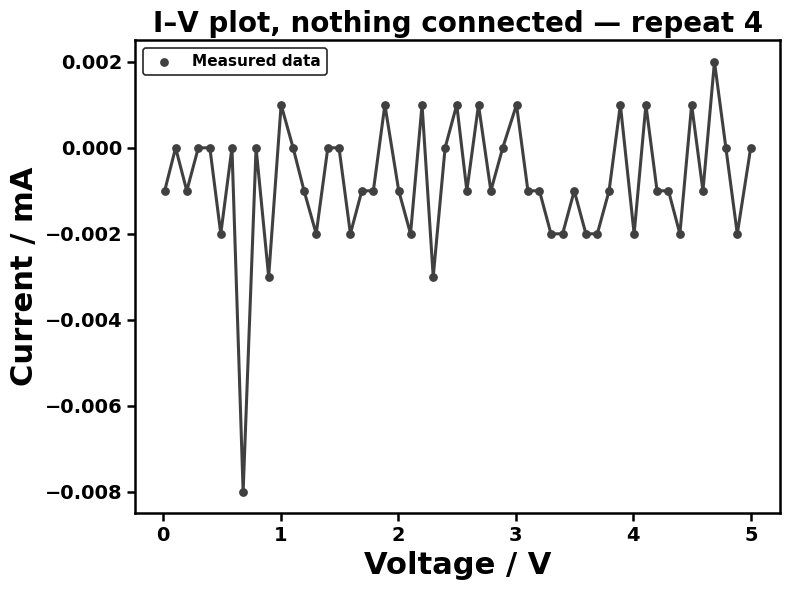

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/3_Open_Circuit_Baseline/open_circuit_run5_20260122_201328.png


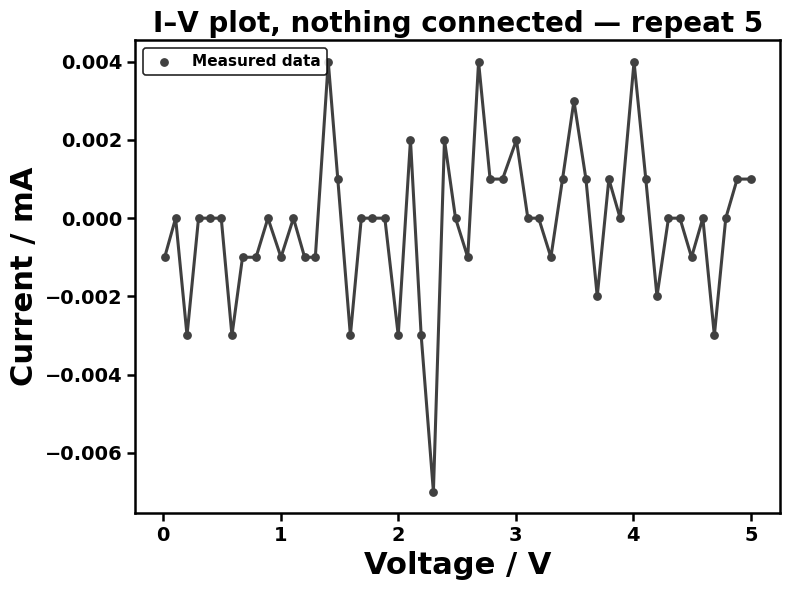

Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/3_Open_Circuit_Baseline/open_circuit_repeats5_20260122_201328.csv

Experiment 3 done.


In [173]:
run_open_circuit_baseline(
     ser,
     repeats=5,
     v_step=0.1,
     delay=0.1,
     Pn=200,
     fit_mode="single",   # change to "double" for both fits
     require_enter_each_run=False
 )

## 2.2. Standard Resistor

**Aim** :

To measure and characterise the current-voltage relationship of a standard resistor, and to demonstrate ohmic conduction as a reference case for comparison with diode based components.

**Explanation** :

The current voltage data for the standard resistor were collected using the same computer controlled acquisition system as for the LED measurements to ensure experimental consistency. The raw data were saved as comma separated value files to facilitate subsequent data processing, averaging, and plotting.

Each measurement was repeated five times at every applied voltage to reduce the influence of random experimental error and improve statistical reliability. The resulting I–V relationship was expected to exhibit a linear dependence, consistent with Ohm’s law, I = V/R.

This session provides a baseline against which the non linear behaviour of LEDs can be clearly contrasted, highlighting the role of intrinsic material properties in determining electrical response.

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/4_Resistor/resistor_run1_20260122_201801.png


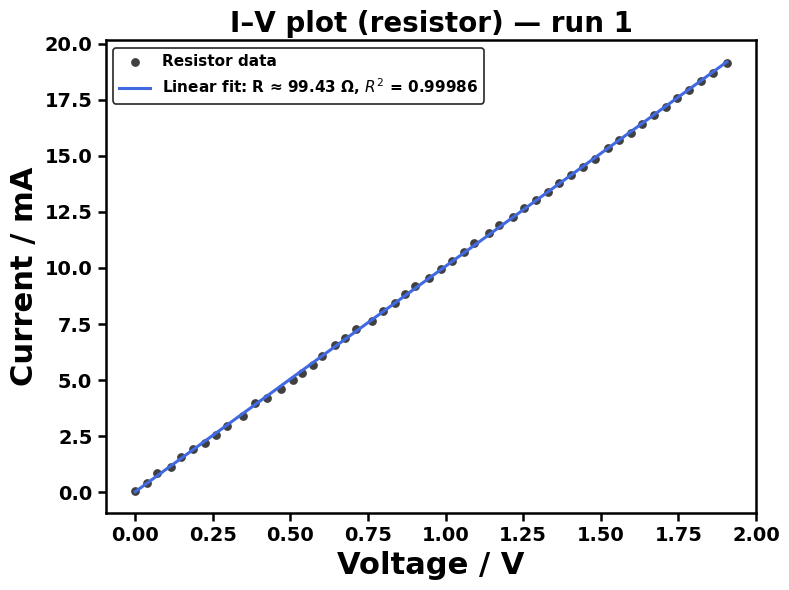

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/4_Resistor/resistor_run2_20260122_201801.png


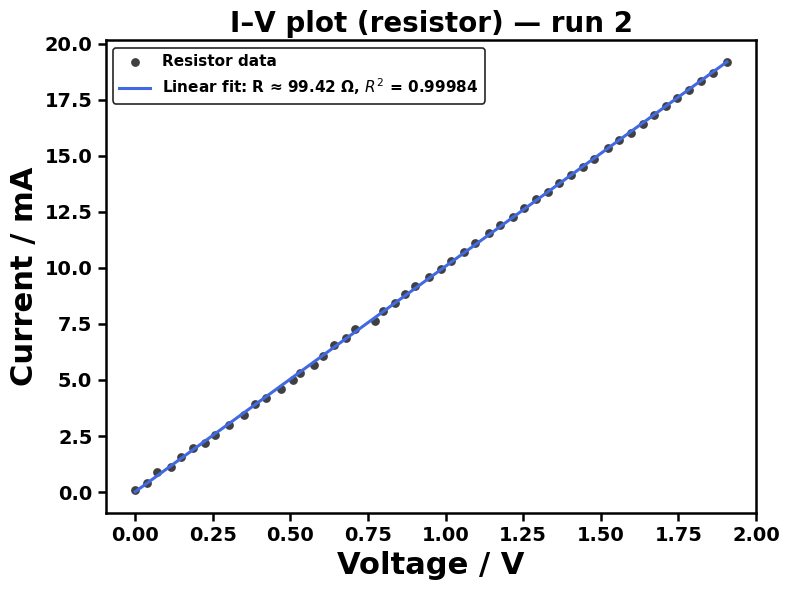

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/4_Resistor/resistor_run3_20260122_201801.png


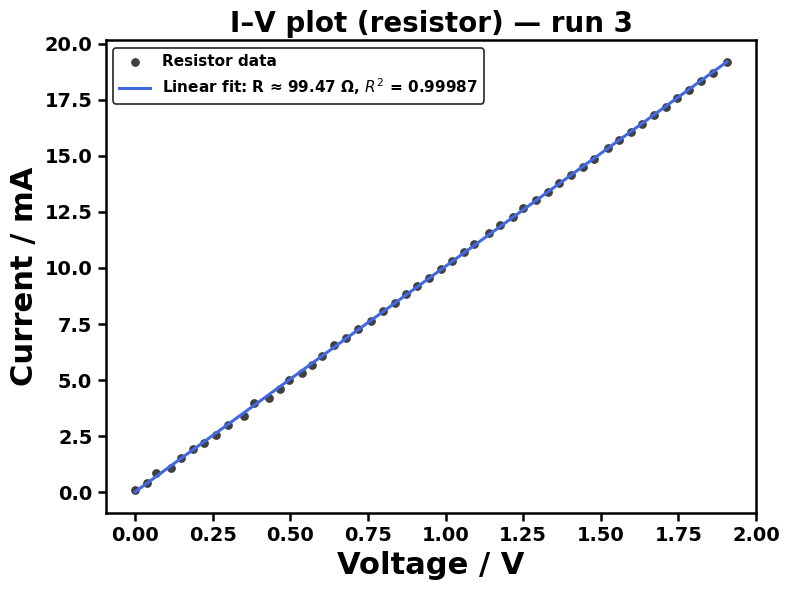

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/4_Resistor/resistor_run4_20260122_201801.png


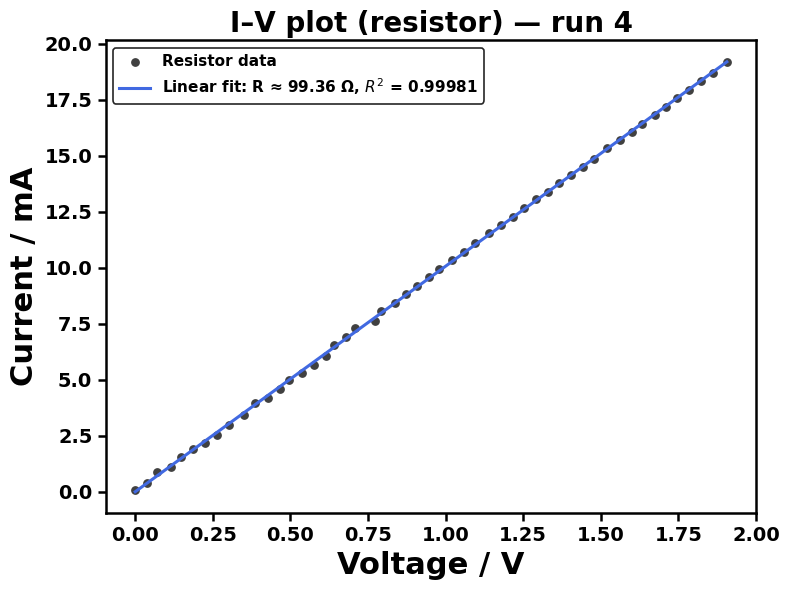

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/4_Resistor/resistor_run5_20260122_201801.png


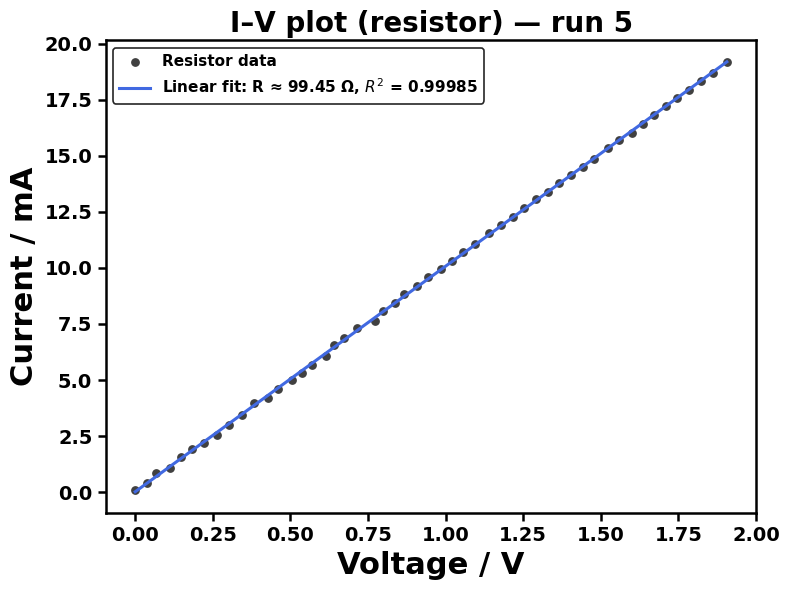

Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/4_Resistor/resistor_repeats5_20260122_201801.csv

Experiment 4 done.


In [183]:
run_resistor_iv_sweep(
     ser,
     repeats=5,
     v_step=0.1,
     delay=0.1,
     Pn=200,
     fit_mode="single",
     require_enter_each_run=False
 )

## 2.3. Colored LED

**Aim** :

To measure the current–voltage characteristics of light emitting diodes and investigate their non-ohmic conduction behaviour, while comparing LEDs of different emission colours to examine the relationship between turn on voltage and semiconductor energy band gap.

**Explanation** :

The applied voltage across each LED was incrementally swept and the resulting current was recorded using a computer controlled acquisition system, with data stored in csv format for efficient processing. The LEDs were measured in the order yellow, red, green, and blue.

The measured I–V curves exhibit non linear behaviour, with minimal current at low voltages followed by a sharp increase beyond a characteristic turn on voltage. This behaviour is governed by charge carrier injection across a pn junction and is described by the Shockley diode equation rather than Ohm’s law. Differences in turn on voltage between LEDs of different colours, including white, were analysed and attributed to variations in semiconductor band gap energy.

In [184]:
led_specs = {
     "Red LED":    {"color": "red",   "V_split": 1.7},
     "Yellow LED": {"color": "gold",  "V_split": 1.8},
     "Green LED":  {"color": "green", "V_split": 1.9},
     "Blue LED":   {"color": "blue",  "V_split": 2.6},
     "White LED":  {"color": "grey",  "V_split": 2.65},
 }


=== Red LED (V_split=1.7) ===


Red LED repeat 1/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Red_LED/Red_LED_run1_20260122_203612.png


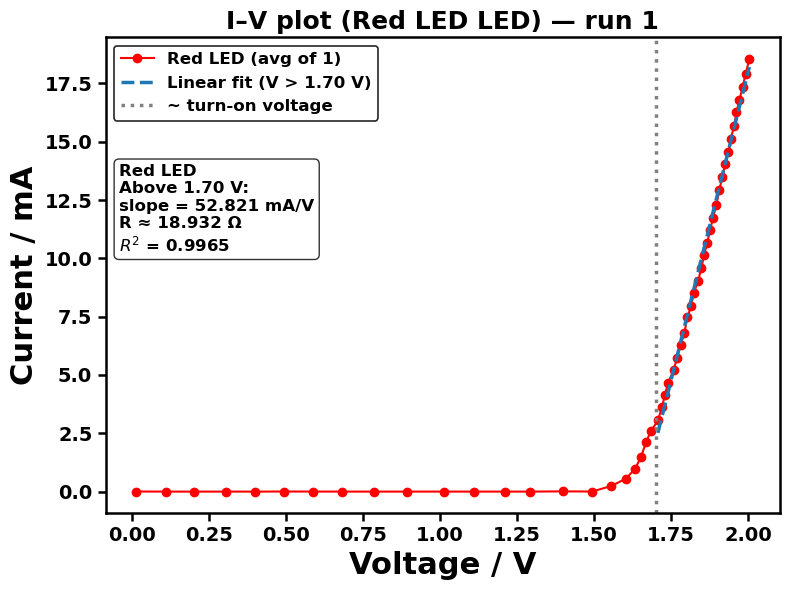

Red LED repeat 2/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Red_LED/Red_LED_run2_20260122_203612.png


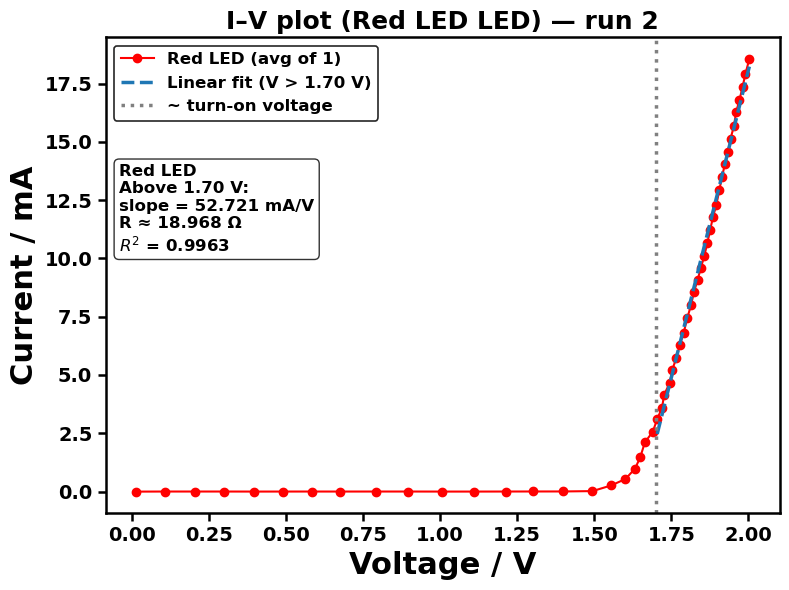

Red LED repeat 3/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Red_LED/Red_LED_run3_20260122_203612.png


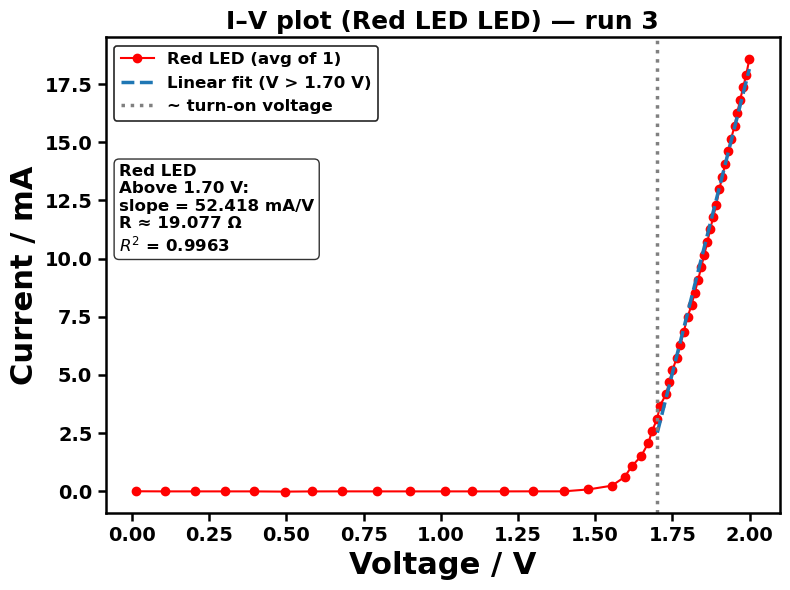

Red LED repeat 4/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Red_LED/Red_LED_run4_20260122_203612.png


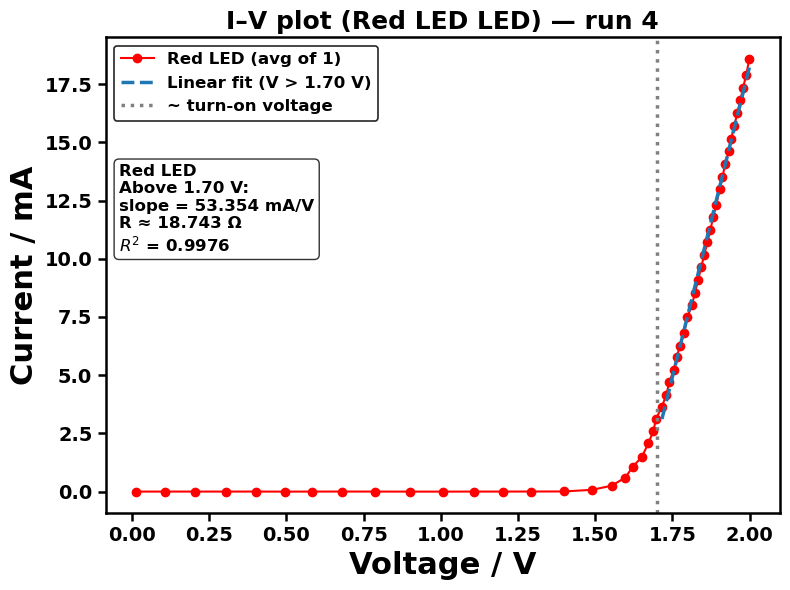

Red LED repeat 5/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Red_LED/Red_LED_run5_20260122_203612.png


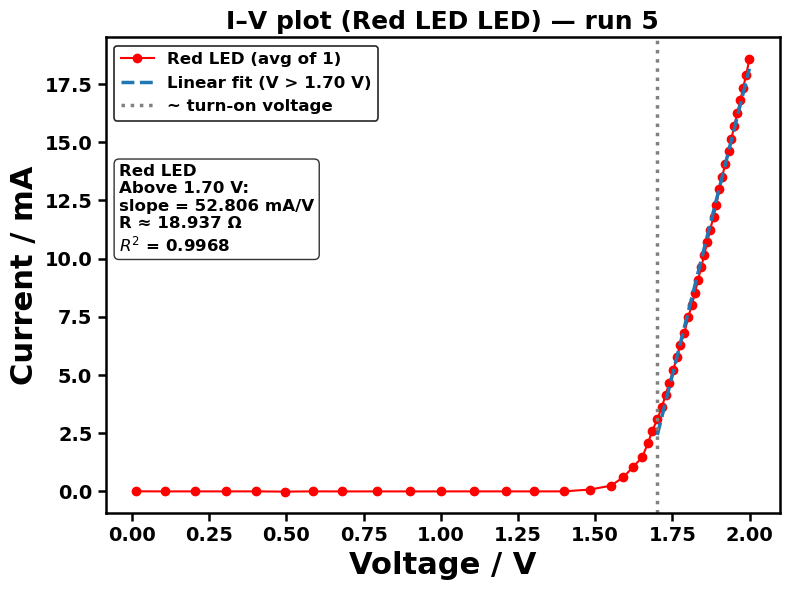

Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/5_LED_Colours/Red_LED/Red_LED_repeats5_20260122_203612.csv

=== Yellow LED (V_split=1.8) ===


Yellow LED repeat 1/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Yellow_LED/Yellow_LED_run1_20260122_203612.png


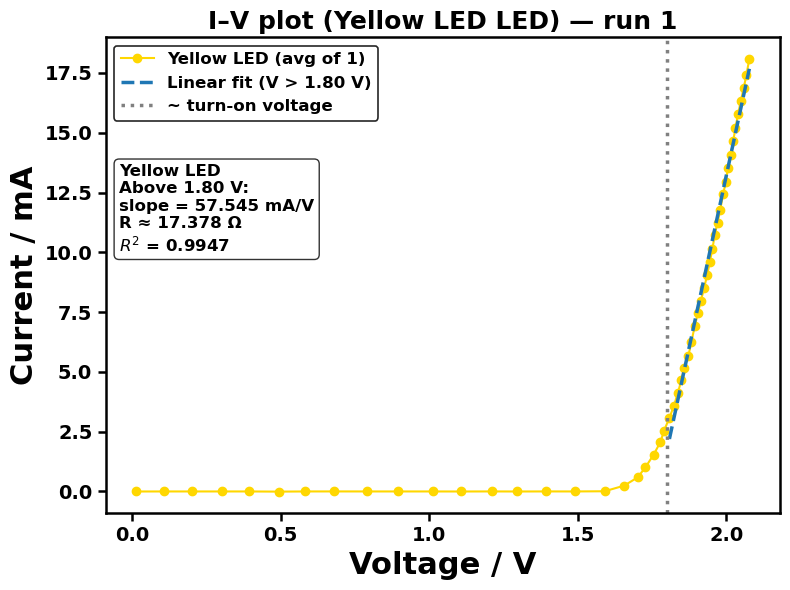

Yellow LED repeat 2/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Yellow_LED/Yellow_LED_run2_20260122_203612.png


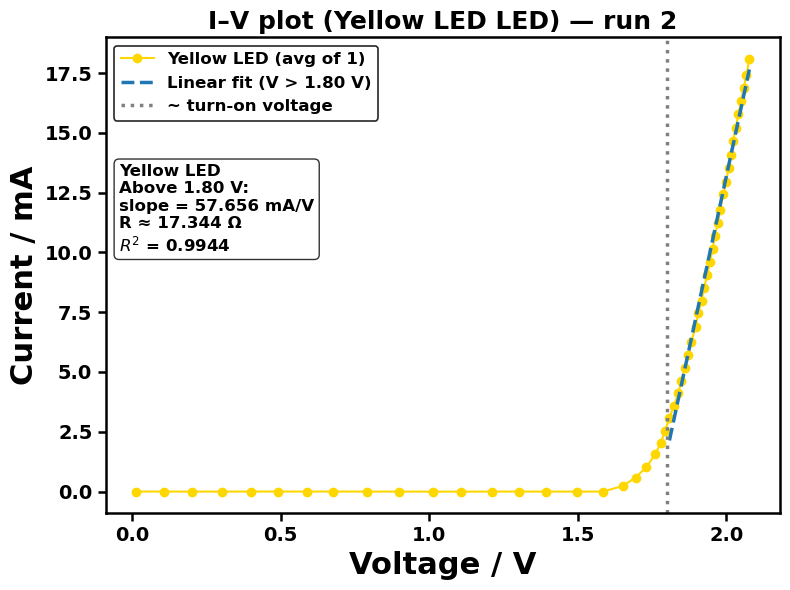

Yellow LED repeat 3/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Yellow_LED/Yellow_LED_run3_20260122_203612.png


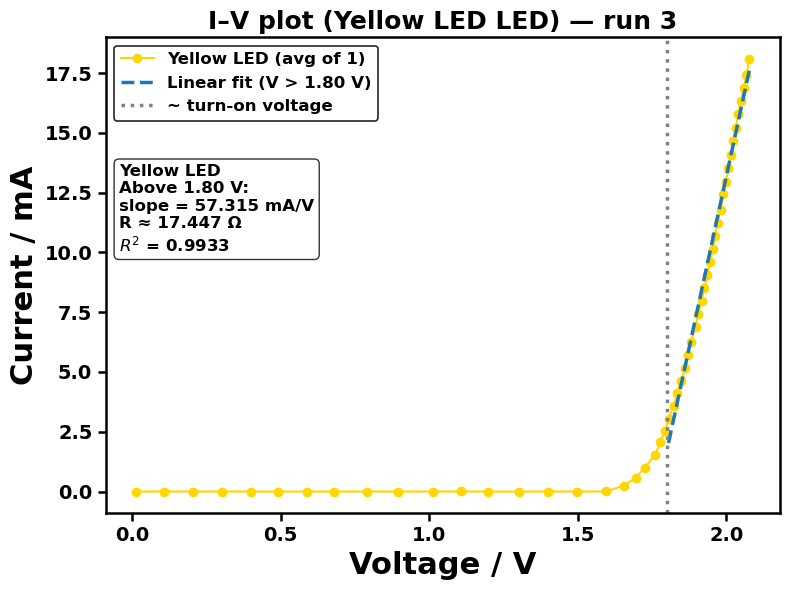

Yellow LED repeat 4/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Yellow_LED/Yellow_LED_run4_20260122_203612.png


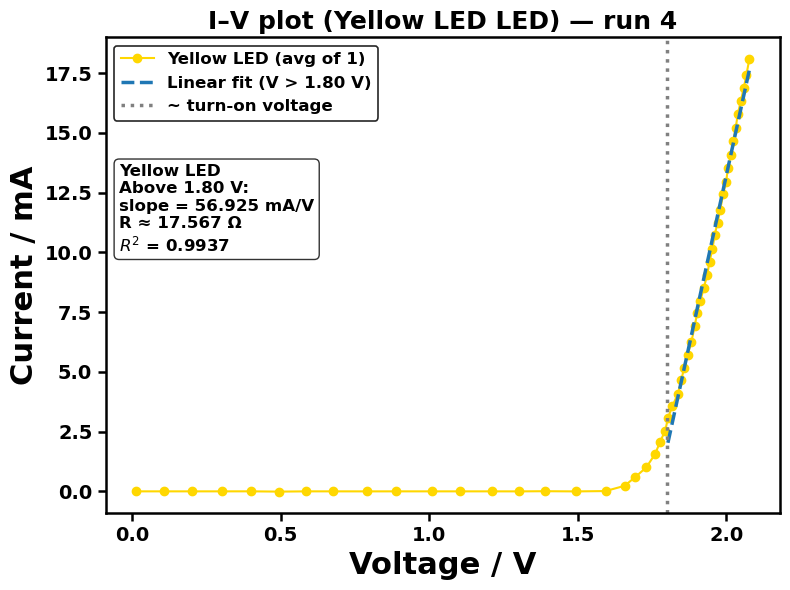

Yellow LED repeat 5/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Yellow_LED/Yellow_LED_run5_20260122_203612.png


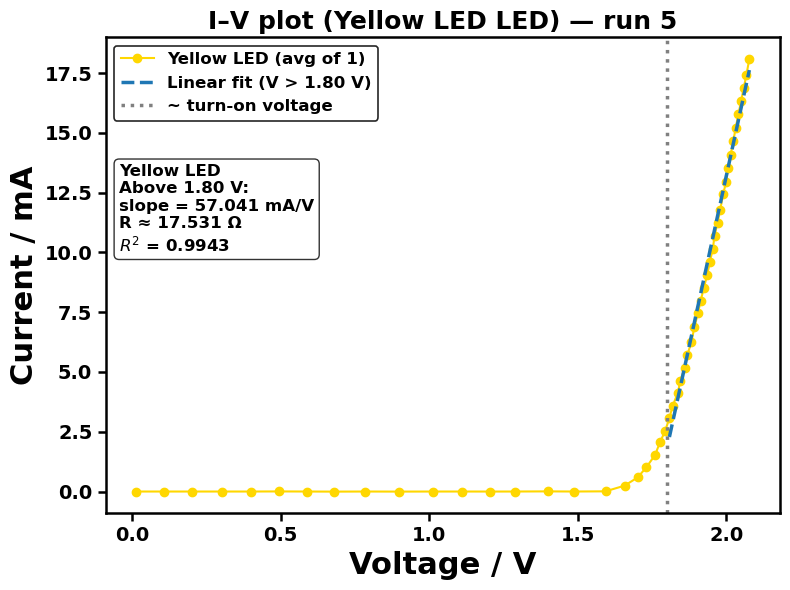

Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/5_LED_Colours/Yellow_LED/Yellow_LED_repeats5_20260122_203612.csv

=== Green LED (V_split=1.9) ===


Green LED repeat 1/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Green_LED/Green_LED_run1_20260122_203612.png


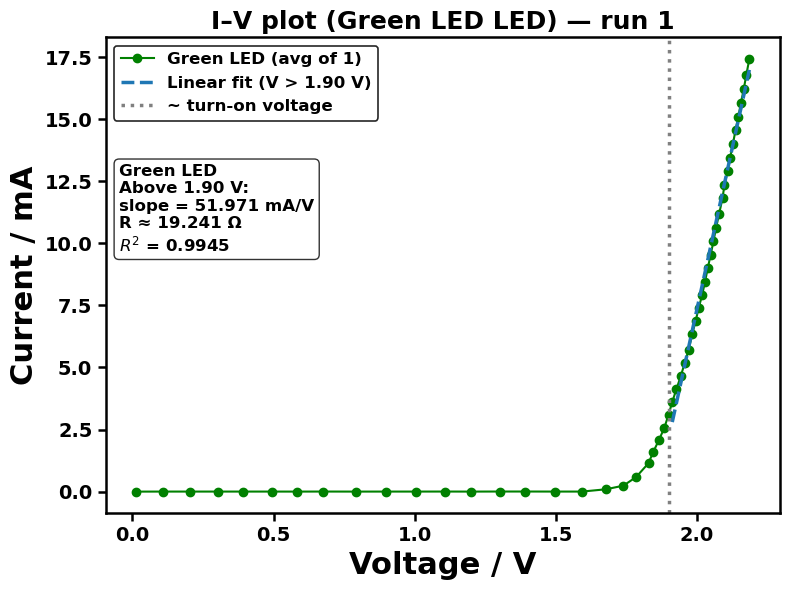

Green LED repeat 2/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Green_LED/Green_LED_run2_20260122_203612.png


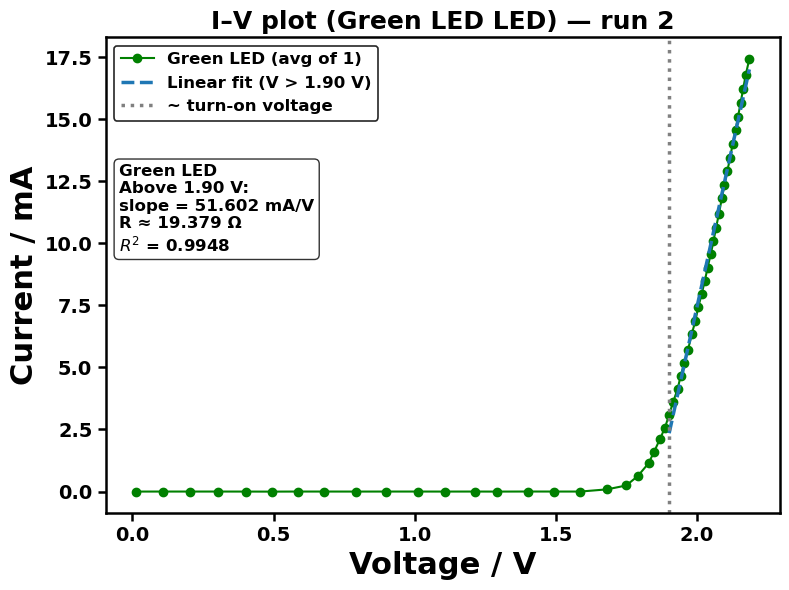

Green LED repeat 3/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Green_LED/Green_LED_run3_20260122_203612.png


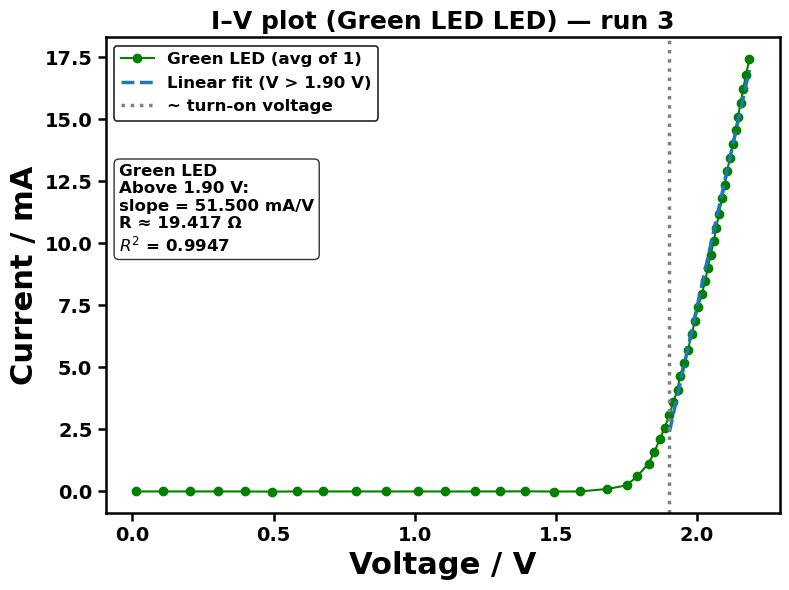

Green LED repeat 4/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Green_LED/Green_LED_run4_20260122_203612.png


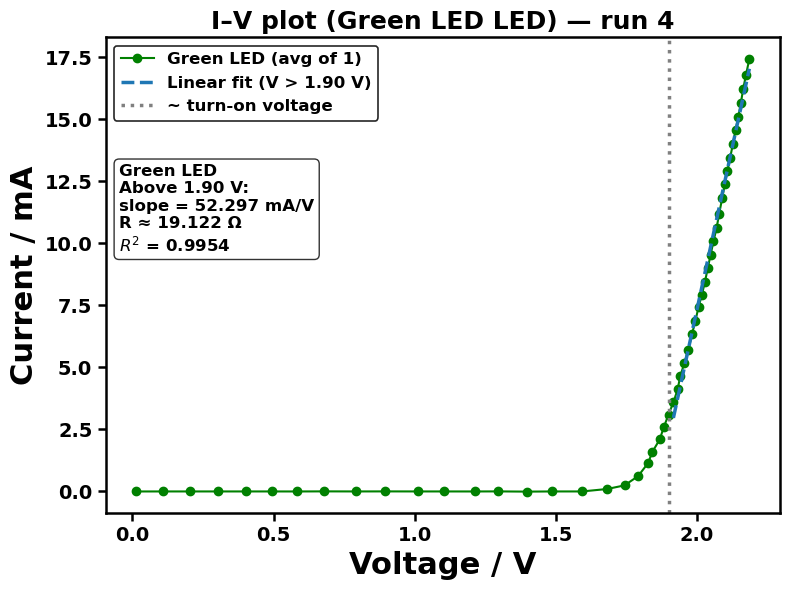

Green LED repeat 5/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Green_LED/Green_LED_run5_20260122_203612.png


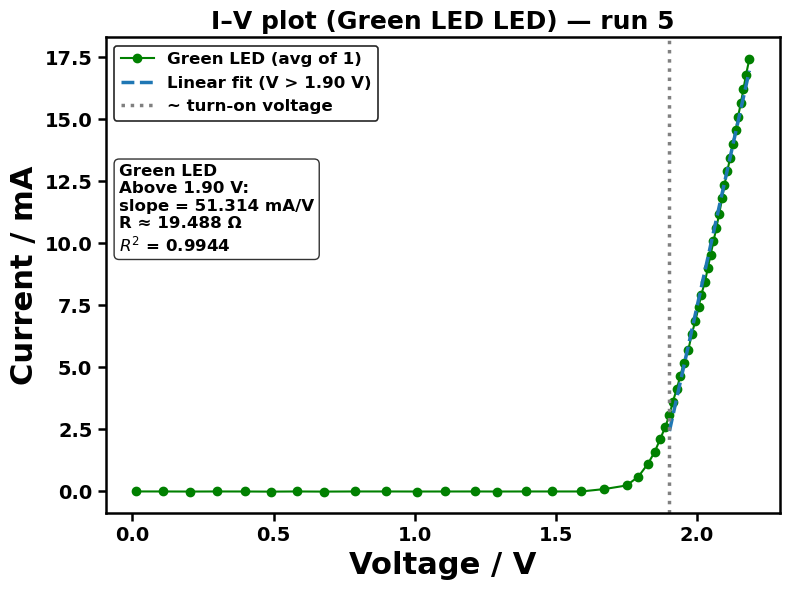

Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/5_LED_Colours/Green_LED/Green_LED_repeats5_20260122_203612.csv

=== Blue LED (V_split=2.6) ===


Blue LED repeat 1/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Blue_LED/Blue_LED_run1_20260122_203612.png


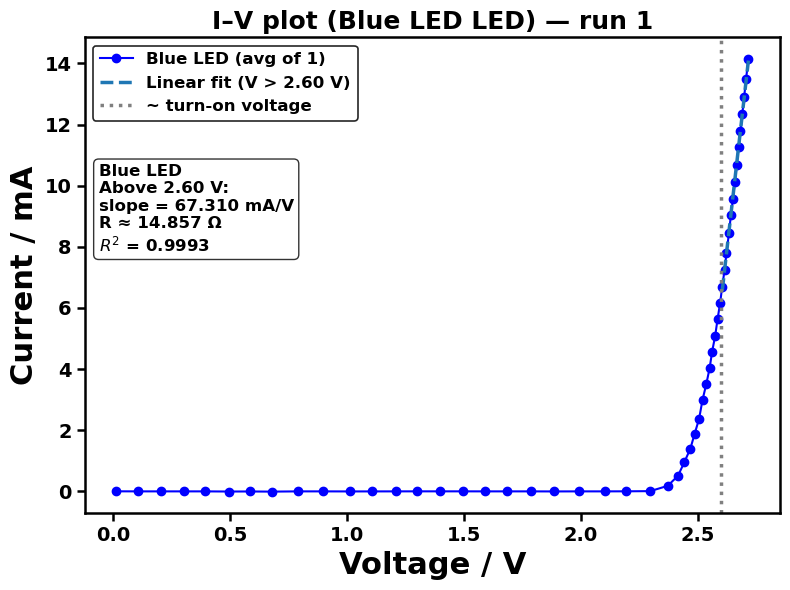

Blue LED repeat 2/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Blue_LED/Blue_LED_run2_20260122_203612.png


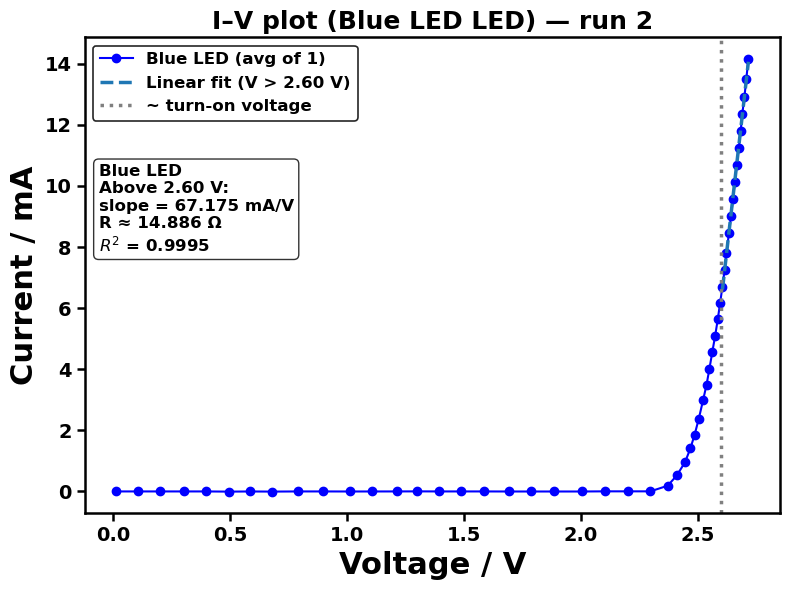

Blue LED repeat 3/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Blue_LED/Blue_LED_run3_20260122_203612.png


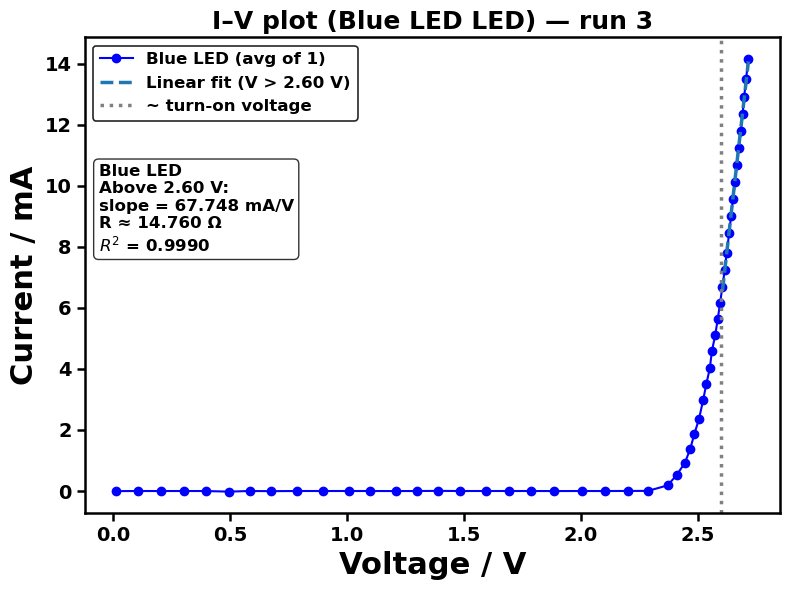

Blue LED repeat 4/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Blue_LED/Blue_LED_run4_20260122_203612.png


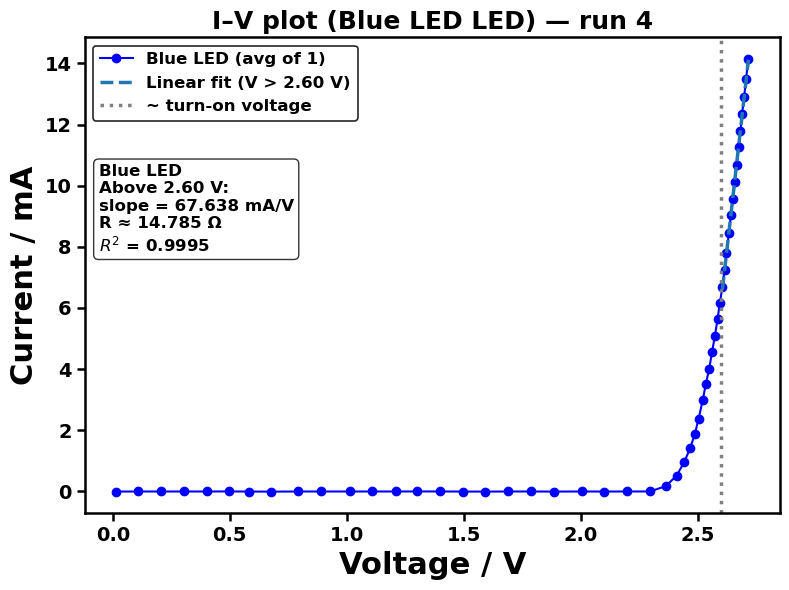

Blue LED repeat 5/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/Blue_LED/Blue_LED_run5_20260122_203612.png


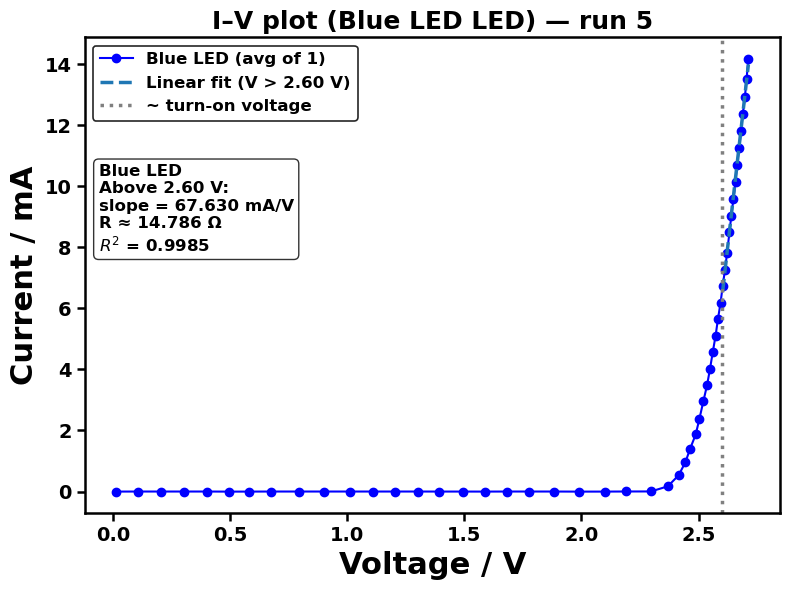

Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/5_LED_Colours/Blue_LED/Blue_LED_repeats5_20260122_203612.csv

=== White LED (V_split=2.65) ===


White LED repeat 1/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/White_LED/White_LED_run1_20260122_203612.png


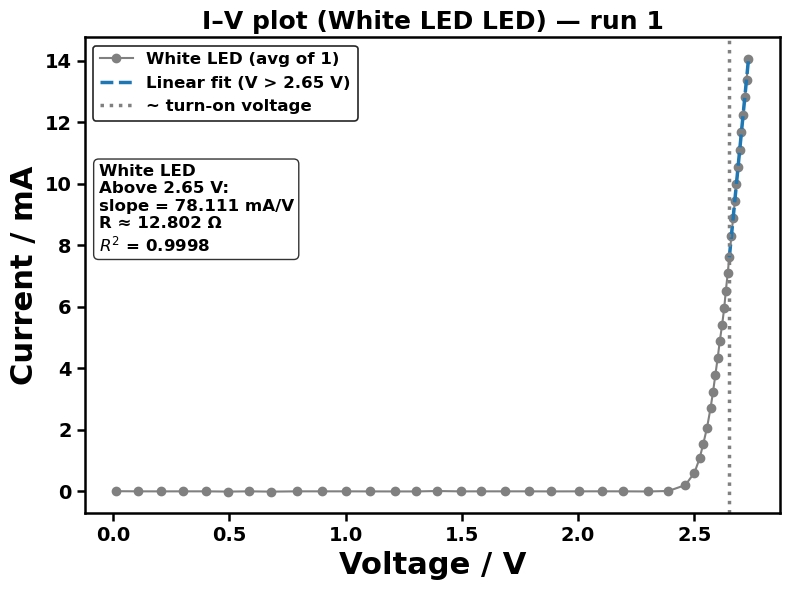

White LED repeat 2/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/White_LED/White_LED_run2_20260122_203612.png


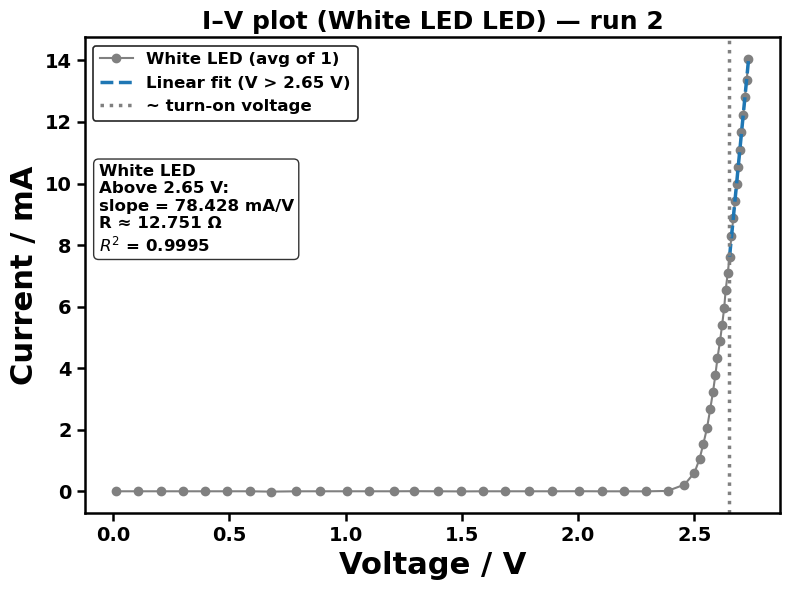

White LED repeat 3/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/White_LED/White_LED_run3_20260122_203612.png


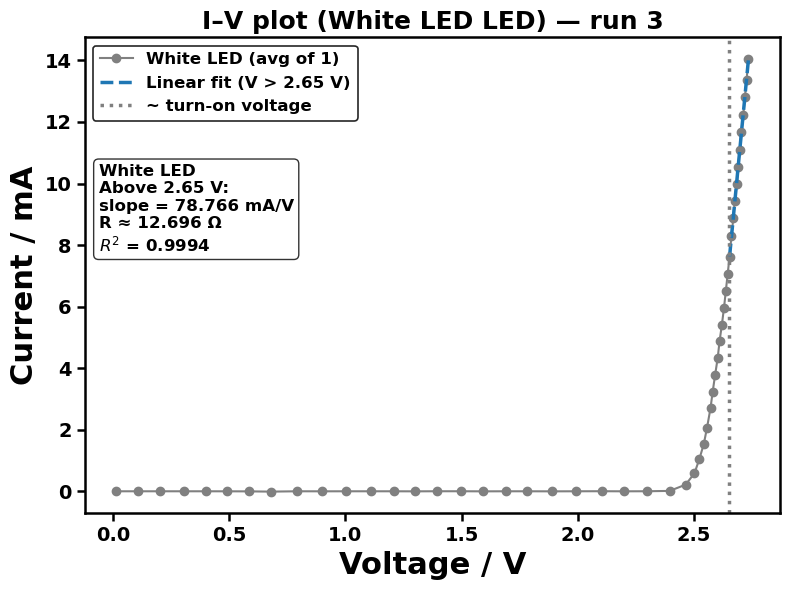

White LED repeat 4/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/White_LED/White_LED_run4_20260122_203612.png


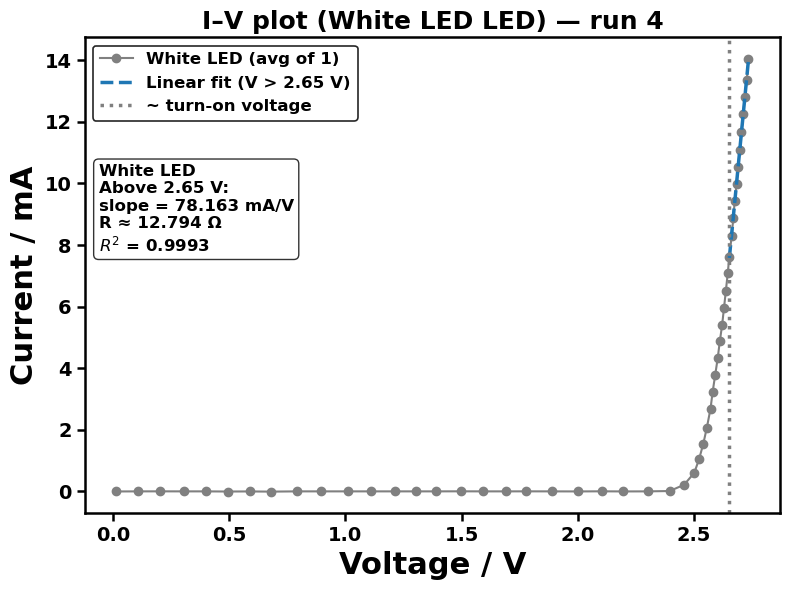

White LED repeat 5/5: press Enter to start... 


Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/5_LED_Colours/White_LED/White_LED_run5_20260122_203612.png


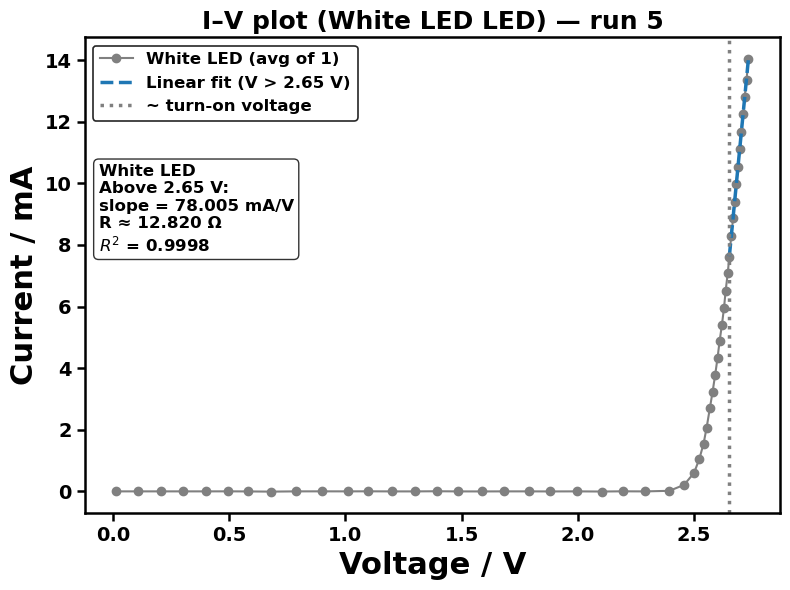

Saved CSV → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised/5_LED_Colours/White_LED/White_LED_repeats5_20260122_203612.csv

Experiment 5 done.


In [200]:
#Colour 1: red as is the order of led_specs.
run_led_colour_set(
     ser,
     led_specs=led_specs,
     repeats=5,
     v_step=0.1,
     delay=0.1,
     Pn=200,
     fit_mode="single",
     require_enter_each_run=True
 )

# 3. Extension - Liquid Nitrogen Cooling
 
**Aim**：

To investigate the effect of temperature on the turn-on voltage of LEDs.

**Explanation**：

The LED I–V characteristics were measured at different temperatures while maintaining consistent voltage sweep parameters. Changes in turn-on voltage were analysed to assess thermal effects on carrier mobility and band gap energy.

A reduction in turn on voltage with increasing temperature is expected due to band gap narrowing and enhanced carrier excitation, providing further evidence that LED behaviour is governed by intrinsic semiconductor physics rather than simple resistive conduction.

In [21]:
def save_iv_csv(filename, V, I):
    """Save (V, I) arrays to CSV."""
    with open(filename, mode='w', newline='') as f:
        w = csv.writer(f)
        w.writerow(["Voltage (V)", "Current (mA)"])
        w.writerows(zip(V, I))
    print(f"Saved: {filename}")
    
def run_led_iv_sweep(
    ser,
    V_split,
    filename="led_IV.csv",
    v_start=0.0,
    v_stop=5.0,
    v_step=0.1,
    delay=0.1,
    Pn=200,
):
    """
    Sweep applied voltage, measure (V_LED, I), do 2 linear fits split by V_split,
    plot, and (optionally) save to CSV.
    Returns: V, I, (m_low, c_low), (m_high, c_high), R_high
    """

    ser.write(f'<P{Pn}>'.encode())
    ser.readline()

    voltages, currents = [], []
    v_set = v_start
    while v_set <= v_stop + 1e-12:
        ser.write(f'<S{v_set:.2f}>'.encode())
        ser.readline()
        time.sleep(delay)

        ser.write(b'<V2>')
        V_meas = float(ser.readline().decode().split()[1])

        ser.write(b'<I1>')
        I_meas = float(ser.readline().decode().split()[1])

        voltages.append(V_meas)
        currents.append(I_meas)
        v_set += v_step

    V = np.array(voltages)
    I = np.array(currents)

    low = V < V_split
    high = V > V_split

    if low.sum() < 2 or high.sum() < 2:
        raise ValueError(
            f"Not enough points for fitting. "
            f"Below split: {low.sum()}, above split: {high.sum()}. "
            f"Try a different V_split."
        )

    m_low, c_low = np.polyfit(V[low], I[low], 1)
    m_high, c_high = np.polyfit(V[high], I[high], 1)

    R_high = 1000 / m_high

    V_fit_low = np.linspace(V[low].min(), V[low].max(), 100)
    V_fit_high = np.linspace(V[high].min(), V[high].max(), 100)
    
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    plt.plot(V, I, 'o', label='Data')
    plt.plot(V_fit_low, m_low * V_fit_low + c_low, '--', label=f'Fit: V < {V_split}', linewidth=2.5)
    plt.plot(V_fit_high, m_high * V_fit_high + c_high, '--', label=f'Fit: V > {V_split}', linewidth=2.5)
    plt.axvline(V_split, linestyle=':', label='Split', color='grey', linewidth=2.5)

    plt.text(
        0.02, 0.6,
        f"Above {V_split:.2f} V:\n"
        f"slope = {m_high:.3f} mA/V\n"
        f"R ≈ {R_high:.3f} Ω",
        transform=plt.gca().transAxes,
        fontsize=14,
        fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
    plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
    plt.xticks(fontsize=14, fontweight='bold')
    plt.yticks(fontsize=14, fontweight='bold')
    plt.title('LED I–V characteristic', fontsize=20, fontweight="bold")
    leg = plt.legend(
    prop={'size': 12, 'weight': 'bold'},
    loc='upper left',
    frameon=True,
    fancybox=True
    )

    frame = leg.get_frame()
    frame.set_facecolor('white')
    frame.set_edgecolor('black')
    frame.set_linewidth(1.2)
    frame.set_alpha(0.85)

    plt.tight_layout()
    plt.show()

    save_iv_csv(filename, V, I) 
    return 

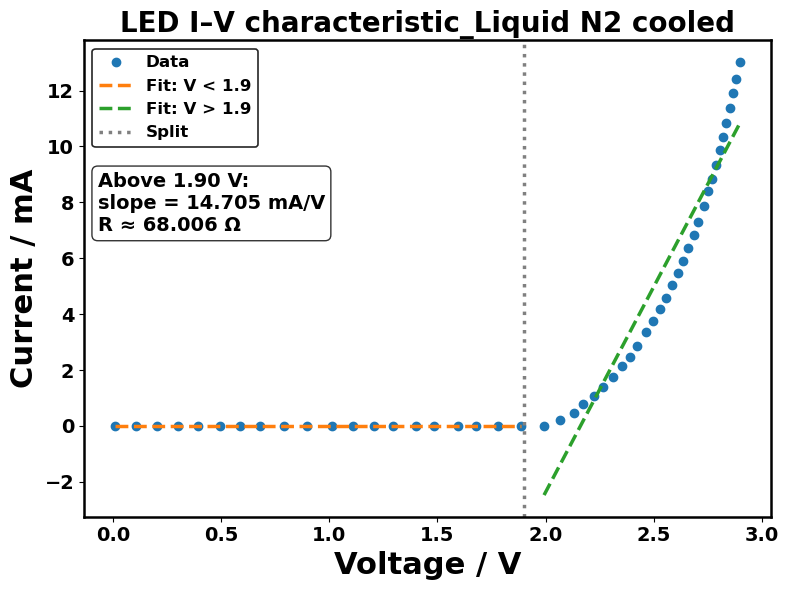

Saved: green_LiquidN2_cooled.csv


In [36]:
run_led_iv_sweep(ser, 1.9, filename="green_LiquidN2_cooled.csv")